# Load Data

In [40]:
TABLE = "price_features"
CALENDAR = "no_calendar"

In [ ]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [42]:
import pandas as pd
import numpy as np
import duckdb

from src.config import (
    DATABASE_PATH,
    ROLLING_WINDOWS,
    LAGGED_WINDOWS,
    MA_WINDOWS,
    TICKERS,
    START_DATE,
    END_DATE
)

from src.features import (
    build_price_feature_columns
)

CALENDAR = "no_calendar"


def pull_calendar_table(table_name: str, calendar: str) -> pd.DataFrame:

    print("[START] Connecting to database...")

    con = duckdb.connect(DATABASE_PATH)

    print(f"[START] Reading {table_name}")

    df = con.sql(f"""
    
        SELECT *
        FROM {table_name}

    """).df()

    print(f"[DONE] Read {table_name}")

    con.close()

    print(f"[START] Building {CALENDAR} required columns...")

    base_cols = [
        "ticker",
        "date",
        "open",
        "high",
        "low",
        "close",
        "adj_close",
        "volume"
    ]

    feature_columns = build_price_feature_columns(
        calendars = [CALENDAR],
        rolling_windows = ROLLING_WINDOWS,
        lagged_windows = LAGGED_WINDOWS,
        ma_windows = MA_WINDOWS
    )

    expected_columns = base_cols + list(feature_columns.keys())

    calendar_df = df[expected_columns].copy()

    print(f"[DONE] Filtered to {CALENDAR}")

    calendar_df["date"] = pd.to_datetime(calendar_df["date"])

    calendar_df = calendar_df.sort_values(["ticker", "date"])

    print(f"[DONE] Prepared and sorted table")

    return calendar_df

In [43]:
df = pull_calendar_table(
    table_name = TABLE,
    calendar = CALENDAR
)

[START] Connecting to database...
[START] Reading price_features
[DONE] Read price_features
[START] Building no_calendar required columns...
[DONE] Filtered to no_calendar
[DONE] Prepared and sorted table


In [44]:
df.columns

Index(['ticker', 'date', 'open', 'high', 'low', 'close', 'adj_close', 'volume',
       'daily_return_no_calendar', 'log_return_no_calendar',
       'cumulative_returns_no_calendar', 'rolling_7d_return_no_calendar',
       'rolling_30d_return_no_calendar', 'lag_1_return_no_calendar',
       'lag_5_return_no_calendar', 'moving_avg_20_no_calendar',
       'moving_avg_50_no_calendar', 'price_vs_ma20_no_calendar',
       'relative_volume_no_calendar', 'rolling_30d_volatility_no_calendar',
       'drawdown_no_calendar', 'target_next_day_return_no_calendar',
       'target_direction_no_calendar'],
      dtype='str')

In [45]:
table_count = 0
graph_count = 0
matrix_count = 0

# Feature Prep

In [46]:
# ============================================================
# FEATURE ANALYSIS: COMMON SETUP
# Run this cell once before the section-specific cells.
# ============================================================

from __future__ import annotations

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display


# ------------------------------------------------------------
# 1. Load and prepare the dataframe
# ------------------------------------------------------------

if "df" not in globals():
    raise NameError(
        "df is not defined. Run:\n"
        "df = pull_calendar_table(...)"
    )

feature_df = df.copy()

TICKER_COL = "ticker"
DATE_COL = "date"
ADJ_CLOSE_COL = "adj_close"
VOLUME_COL = "volume"

DAILY_RETURN_COL = "daily_return_no_calendar"
LOG_RETURN_COL = "log_return_no_calendar"
CUMULATIVE_RETURN_COL = "cumulative_returns_no_calendar"

ROLLING_7_RETURN_COL = "rolling_7d_return_no_calendar"
ROLLING_30_RETURN_COL = "rolling_30d_return_no_calendar"

LAG_1_RETURN_COL = "lag_1_return_no_calendar"
LAG_5_RETURN_COL = "lag_5_return_no_calendar"

MA20_COL = "moving_avg_20_no_calendar"
MA50_COL = "moving_avg_50_no_calendar"
PRICE_VS_MA20_COL = "price_vs_ma20_no_calendar"

RELATIVE_VOLUME_COL = "relative_volume_no_calendar"
ROLLING_VOLATILITY_COL = "rolling_30d_volatility_no_calendar"
DRAWDOWN_COL = "drawdown_no_calendar"

TARGET_RETURN_COL = "target_next_day_return_no_calendar"
TARGET_DIRECTION_COL = "target_direction_no_calendar"


ENGINEERED_FEATURES = [
    DAILY_RETURN_COL,
    LOG_RETURN_COL,
    CUMULATIVE_RETURN_COL,
    ROLLING_7_RETURN_COL,
    ROLLING_30_RETURN_COL,
    LAG_1_RETURN_COL,
    LAG_5_RETURN_COL,
    MA20_COL,
    MA50_COL,
    PRICE_VS_MA20_COL,
    RELATIVE_VOLUME_COL,
    ROLLING_VOLATILITY_COL,
    DRAWDOWN_COL,
    TARGET_RETURN_COL,
    TARGET_DIRECTION_COL,
]

PREDICTOR_FEATURES = [
    DAILY_RETURN_COL,
    LOG_RETURN_COL,
    ROLLING_7_RETURN_COL,
    ROLLING_30_RETURN_COL,
    LAG_1_RETURN_COL,
    LAG_5_RETURN_COL,
    MA20_COL,
    MA50_COL,
    PRICE_VS_MA20_COL,
    RELATIVE_VOLUME_COL,
    ROLLING_VOLATILITY_COL,
    DRAWDOWN_COL,
]


required_columns = [
    TICKER_COL,
    DATE_COL,
    ADJ_CLOSE_COL,
    VOLUME_COL,
    *ENGINEERED_FEATURES,
]

missing_columns = [
    column for column in required_columns
    if column not in feature_df.columns
]

if missing_columns:
    raise KeyError(
        "The following required columns are missing:\n"
        f"{missing_columns}"
    )

feature_df[DATE_COL] = pd.to_datetime(
    feature_df[DATE_COL],
    errors="coerce"
)

feature_df = (
    feature_df
    .sort_values([TICKER_COL, DATE_COL])
    .reset_index(drop=True)
)

TICKERS_IN_DATA = (
    feature_df[TICKER_COL]
    .dropna()
    .drop_duplicates()
    .tolist()
)

duplicate_rows = feature_df.duplicated(
    subset=[TICKER_COL, DATE_COL],
    keep=False
)

if duplicate_rows.any():
    print(
        f"WARNING: {duplicate_rows.sum():,} rows have duplicate "
        "ticker-date combinations."
    )

print(f"Rows: {len(feature_df):,}")
print(f"Tickers: {len(TICKERS_IN_DATA)}")
print(f"Date range: {feature_df[DATE_COL].min()} to {feature_df[DATE_COL].max()}")
print(f"Tickers found: {TICKERS_IN_DATA}")


# ------------------------------------------------------------
# 2. Independent recalculation settings
# Change these to match src.features exactly.
# ------------------------------------------------------------

RELATIVE_VOLUME_WINDOW = 20

# 0 means the current day's volume is included in the
# rolling-volume denominator.
#
# 1 means only prior observations are used in the denominator.
RELATIVE_VOLUME_BASELINE_SHIFT = 0

# Use 1.0 when price_vs_ma20 is stored as a decimal:
#     0.05 = 5% above MA20
#
# Use 100.0 when stored in percentage points:
#     5.0 = 5% above MA20
PRICE_VS_MA20_MULTIPLIER = 1.0

# Use 1.0 for unannualised rolling volatility.
# Use np.sqrt(252) if the feature is annualised.
VOLATILITY_ANNUALISATION_FACTOR = 1.0

ROLLING_VOLATILITY_WINDOW = 30

NUMERICAL_ATOL = 1e-10
NUMERICAL_RTOL = 1e-7


# ------------------------------------------------------------
# 3. General helper functions
# ------------------------------------------------------------

def finite_numeric(series: pd.Series) -> pd.Series:
    """Return finite numeric values only."""
    numeric = pd.to_numeric(series, errors="coerce")
    return numeric[np.isfinite(numeric)]


def first_valid_position(series: pd.Series) -> int | None:
    """Return the zero-based position of the first non-null value."""
    positions = np.flatnonzero(series.notna().to_numpy())

    if len(positions) == 0:
        return None

    return int(positions[0])


def last_valid_position(series: pd.Series) -> int | None:
    """Return the zero-based position of the last non-null value."""
    positions = np.flatnonzero(series.notna().to_numpy())

    if len(positions) == 0:
        return None

    return int(positions[-1])


def first_valid_date(
    group: pd.DataFrame,
    column: str
) -> pd.Timestamp | pd.NaT:
    """Return the first date on which a feature is available."""
    position = first_valid_position(group[column])

    if position is None:
        return pd.NaT

    return group.iloc[position][DATE_COL]


def longest_true_run(mask: pd.Series | np.ndarray) -> int:
    """Return the longest consecutive run of True values."""
    values = np.asarray(mask, dtype=bool)

    longest = 0
    current = 0

    for value in values:
        if value:
            current += 1
            longest = max(longest, current)
        else:
            current = 0

    return longest


def longest_constant_run(
    series: pd.Series,
    tolerance: float = 1e-12
) -> int:
    """Return the longest run where consecutive values barely change."""
    numeric = pd.to_numeric(series, errors="coerce")

    unchanged = (
        numeric.diff().abs().le(tolerance)
        & numeric.notna()
        & numeric.shift(1).notna()
    )

    return longest_true_run(unchanged)


def robust_outlier_count(
    series: pd.Series,
    threshold: float = 10.0
) -> int:
    """
    Count extreme observations using the modified z-score.

    A high threshold is used because this is a validity check,
    not ordinary statistical outlier removal.
    """
    values = finite_numeric(series)

    if len(values) < 5:
        return 0

    median = values.median()
    mad = np.median(np.abs(values - median))

    if mad == 0 or np.isnan(mad):
        return 0

    modified_z = 0.6745 * (values - median) / mad

    return int((modified_z.abs() > threshold).sum())


def make_ticker_grid(
    n_items: int,
    ncols: int = 2,
    figure_width: float = 16,
    row_height: float = 3.6,
    sharex: bool = False
):
    """Create a subplot grid and hide unused axes."""
    nrows = math.ceil(n_items / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(figure_width, row_height * nrows),
        squeeze=False,
        sharex=sharex,
    )

    axes = axes.flatten()

    for axis in axes[n_items:]:
        axis.set_visible(False)

    return fig, axes


def ecdf_values(series: pd.Series) -> tuple[np.ndarray, np.ndarray]:
    """Return x and y values for an empirical CDF."""
    values = np.sort(finite_numeric(series).to_numpy())

    if len(values) == 0:
        return np.array([]), np.array([])

    probabilities = np.arange(1, len(values) + 1) / len(values)

    return values, probabilities


# ------------------------------------------------------------
# 4. Independent feature recalculation
# ------------------------------------------------------------

def recalculate_features(data: pd.DataFrame) -> pd.DataFrame:
    """
    Independently rebuild the engineered features.

    These formulas must match src.features for the reconciliation
    results to pass.
    """
    data = (
        data
        .sort_values([TICKER_COL, DATE_COL])
        .copy()
    )

    expected = pd.DataFrame(index=data.index)

    ticker_values = data[TICKER_COL]

    grouped_price = data.groupby(
        TICKER_COL,
        sort=False
    )[ADJ_CLOSE_COL]

    grouped_volume = data.groupby(
        TICKER_COL,
        sort=False
    )[VOLUME_COL]

    # Daily simple return
    expected[DAILY_RETURN_COL] = grouped_price.transform(
        lambda series: series.pct_change(fill_method=None)
    )

    # Daily log return
    expected[LOG_RETURN_COL] = grouped_price.transform(
        lambda series: np.log(series).diff()
    )

    # Cumulative compounded return
    expected[CUMULATIVE_RETURN_COL] = (
        expected[DAILY_RETURN_COL]
        .groupby(ticker_values, sort=False)
        .transform(lambda series: (1.0 + series).cumprod() - 1.0)
    )

    # Rolling/cumulative return over observation windows
    expected[ROLLING_7_RETURN_COL] = grouped_price.transform(
        lambda series: series.div(series.shift(7)).sub(1.0)
    )

    expected[ROLLING_30_RETURN_COL] = grouped_price.transform(
        lambda series: series.div(series.shift(30)).sub(1.0)
    )

    # Lagged daily returns
    expected[LAG_1_RETURN_COL] = (
        expected[DAILY_RETURN_COL]
        .groupby(ticker_values, sort=False)
        .shift(1)
    )

    expected[LAG_5_RETURN_COL] = (
        expected[DAILY_RETURN_COL]
        .groupby(ticker_values, sort=False)
        .shift(5)
    )

    # Moving averages
    expected[MA20_COL] = grouped_price.transform(
        lambda series: series.rolling(
            window=20,
            min_periods=20
        ).mean()
    )

    expected[MA50_COL] = grouped_price.transform(
        lambda series: series.rolling(
            window=50,
            min_periods=50
        ).mean()
    )

    # Price relative to MA20
    ma20_denominator = expected[MA20_COL].replace(0, np.nan)

    expected[PRICE_VS_MA20_COL] = (
        data[ADJ_CLOSE_COL]
        .div(ma20_denominator)
        .sub(1.0)
        .mul(PRICE_VS_MA20_MULTIPLIER)
    )

    # Relative volume
    volume_baseline = grouped_volume.transform(
        lambda series: (
            series
            .shift(RELATIVE_VOLUME_BASELINE_SHIFT)
            .rolling(
                window=RELATIVE_VOLUME_WINDOW,
                min_periods=RELATIVE_VOLUME_WINDOW
            )
            .mean()
        )
    )

    expected[RELATIVE_VOLUME_COL] = (
        data[VOLUME_COL]
        .div(volume_baseline.replace(0, np.nan))
    )

    # Rolling return volatility
    expected[ROLLING_VOLATILITY_COL] = (
        expected[DAILY_RETURN_COL]
        .groupby(ticker_values, sort=False)
        .transform(
            lambda series: series.rolling(
                window=ROLLING_VOLATILITY_WINDOW,
                min_periods=ROLLING_VOLATILITY_WINDOW
            ).std(ddof=1)
        )
        .mul(VOLATILITY_ANNUALISATION_FACTOR)
    )

    # Drawdown from the running adjusted-close maximum
    running_max = grouped_price.transform(
        lambda series: series.cummax()
    )

    expected[DRAWDOWN_COL] = (
        data[ADJ_CLOSE_COL]
        .div(running_max.replace(0, np.nan))
        .sub(1.0)
    )

    # Next-observation target
    expected[TARGET_RETURN_COL] = (
        expected[DAILY_RETURN_COL]
        .groupby(ticker_values, sort=False)
        .shift(-1)
    )

    expected[TARGET_DIRECTION_COL] = np.where(
        expected[TARGET_RETURN_COL].isna(),
        np.nan,
        (expected[TARGET_RETURN_COL] > 0).astype(float)
    )

    return expected


print("Common feature-analysis setup complete.")

Rows: 11,534
Tickers: 7
Date range: 2018-01-02 00:00:00 to 2026-06-30 00:00:00
Tickers found: ['GLD', 'MU', 'NKE', 'RPI.L', 'SNDK', 'SPY', 'TLT']
Common feature-analysis setup complete.


# Global Validation

Table 1:


,Feature,Independent formula,Window or lag,Expected behaviour
0,daily_return_no_calendar,adj_close / adj_close.shift(1) - 1,1,Signed; first observation per ticker is NaN
1,log_return_no_calendar,log(adj_close).diff(),1,Signed; requires positive adjusted prices
2,cumulative_returns_no_calendar,cumprod(1 + daily_return) - 1,Expanding,Path-dependent cumulative performance
3,rolling_7d_return_no_calendar,adj_close / adj_close.shift(7) - 1,7,First seven observations normally NaN
4,rolling_30d_return_no_calendar,adj_close / adj_close.shift(30) - 1,30,First 30 observations normally NaN
5,lag_1_return_no_calendar,daily_return.shift(1),1,Uses only a previous observation
6,lag_5_return_no_calendar,daily_return.shift(5),5,Uses only a previous observation
7,moving_avg_20_no_calendar,adj_close.rolling(20).mean(),20,First 19 observations normally NaN
8,moving_avg_50_no_calendar,adj_close.rolling(50).mean(),50,First 49 observations normally NaN
9,price_vs_ma20_no_calendar,adj_close / MA20 - 1,20,Zero near MA20; signed around zero


Table 2:


,Feature,Tickers_checked,Tickers_passing,Total_mismatched_rows,Maximum_absolute_error,NaN_pattern_mismatches,Status
0,cumulative_returns_no_calendar,7,7,0,0.000000e+00,0,Pass
1,daily_return_no_calendar,7,7,0,0.000000e+00,0,Pass
2,drawdown_no_calendar,7,7,0,0.000000e+00,0,Pass
3,lag_1_return_no_calendar,7,7,0,0.000000e+00,0,Pass
4,lag_5_return_no_calendar,7,7,0,0.000000e+00,0,Pass
5,log_return_no_calendar,7,7,0,9.645063e-16,0,Pass
6,moving_avg_20_no_calendar,7,7,0,0.000000e+00,0,Pass
7,moving_avg_50_no_calendar,7,7,0,0.000000e+00,0,Pass
8,price_vs_ma20_no_calendar,7,7,0,0.000000e+00,0,Pass
9,relative_volume_no_calendar,7,7,0,0.000000e+00,0,Pass


All independently recalculated features match.
Table 3:


...

No structural feature-health issues were detected.
Table 4:


Feature,cumulative_returns_no_calendar,daily_return_no_calendar,drawdown_no_calendar,lag_1_return_no_calendar,lag_5_return_no_calendar,log_return_no_calendar,moving_avg_20_no_calendar,moving_avg_50_no_calendar,price_vs_ma20_no_calendar,relative_volume_no_calendar,rolling_30d_return_no_calendar,rolling_30d_volatility_no_calendar,rolling_7d_return_no_calendar,target_direction_no_calendar,target_next_day_return_no_calendar
Ticker,,,,,,,,,,,,,,,
GLD,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass
MU,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass
NKE,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass
RPI.L,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass
SNDK,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass
SPY,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass
TLT,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass,Pass


Table 5:


,daily_return_no_calendar,log_return_no_calendar,cumulative_returns_no_calendar,rolling_7d_return_no_calendar,rolling_30d_return_no_calendar,lag_1_return_no_calendar,lag_5_return_no_calendar,moving_avg_20_no_calendar,moving_avg_50_no_calendar,price_vs_ma20_no_calendar,relative_volume_no_calendar,rolling_30d_volatility_no_calendar,drawdown_no_calendar,target_next_day_return_no_calendar,target_direction_no_calendar
ticker,,,,,,,,,,,,,,,
GLD,0.05,0.05,0.05,0.33,1.41,0.09,0.28,0.89,2.30,0.89,0.89,1.41,0.0,0.05,0.05
MU,0.05,0.05,0.05,0.33,1.41,0.09,0.28,0.89,2.30,0.89,0.89,1.41,0.0,0.05,0.05
NKE,0.05,0.05,0.05,0.33,1.41,0.09,0.28,0.89,2.30,0.89,0.89,1.41,0.0,0.05,0.05
RPI.L,0.19,0.19,0.19,1.35,5.78,0.39,1.16,3.66,9.44,3.66,3.66,5.78,0.0,0.19,0.19
SNDK,0.29,0.29,0.29,2.03,8.70,0.58,1.74,5.51,14.20,5.51,5.51,8.70,0.0,0.29,0.29
SPY,0.05,0.05,0.05,0.33,1.41,0.09,0.28,0.89,2.30,0.89,0.89,1.41,0.0,0.05,0.05
TLT,0.05,0.05,0.05,0.33,1.41,0.09,0.28,0.89,2.30,0.89,0.89,1.41,0.0,0.05,0.05


Graph 1


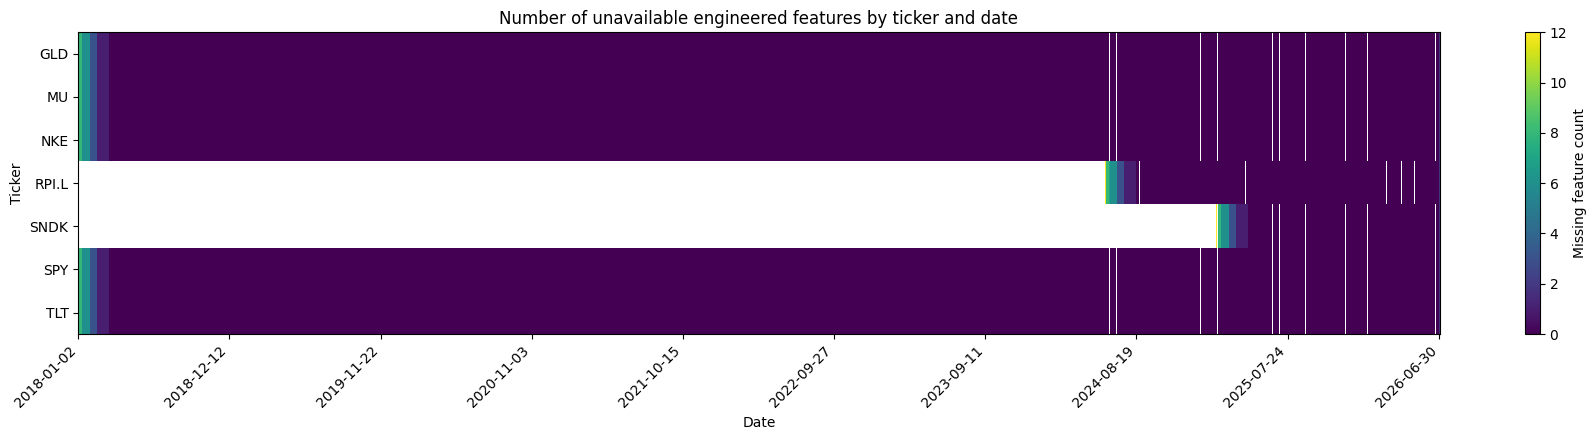

Table 6:


,Feature,Rule,Total_violations,Tickers_affected
0,adj_close,Adjusted close must be greater than zero,0,0
1,daily_return_no_calendar,Simple return must normally be greater than -1,0,0
2,drawdown_no_calendar,Drawdown must normally be between -1 and 0,0,0
3,moving_avg_20_no_calendar,MA20 must be positive when available,0,0
4,moving_avg_50_no_calendar,MA50 must be positive when available,0,0
5,price_vs_ma20_no_calendar,Sign must match adj_close - MA20,0,0
6,relative_volume_no_calendar,Relative volume must be non-negative,0,0
7,rolling_30d_return_no_calendar,Thirty-observation simple return must be great...,0,0
8,rolling_30d_volatility_no_calendar,Rolling volatility must be non-negative,0,0
9,rolling_7d_return_no_calendar,Seven-observation simple return must be greate...,0,0


No expected-domain violations were detected.
Table 7:


,ticker,Zero_volume_days,Total_rows,Zero-volume %
0,GLD,0,2134,0.0
1,MU,0,2134,0.0
2,NKE,0,2134,0.0
3,RPI.L,0,519,0.0
4,SNDK,0,345,0.0
5,SPY,0,2134,0.0
6,TLT,0,2134,0.0


Table 8:


,Feature,Uses current row,Uses past rows,Uses future rows,Grouped by ticker,Available after current close,Predictor or target
0,daily_return_no_calendar,True,True,False,True,True,Predictor
1,log_return_no_calendar,True,True,False,True,True,Predictor
2,rolling_7d_return_no_calendar,True,True,False,True,True,Predictor
3,rolling_30d_return_no_calendar,True,True,False,True,True,Predictor
4,lag_1_return_no_calendar,False,True,False,True,True,Predictor
5,lag_5_return_no_calendar,False,True,False,True,True,Predictor
6,moving_avg_20_no_calendar,True,True,False,True,True,Predictor
7,moving_avg_50_no_calendar,True,True,False,True,True,Predictor
8,price_vs_ma20_no_calendar,True,True,False,True,True,Predictor
9,relative_volume_no_calendar,True,True,False,True,True,Predictor


Leakage interpretation: current close and current volume are only available when predictions are generated after the trading session.


In [47]:
# ============================================================
# SECTION: CHECKING SENSIBLE FEATURE VALUES
# ============================================================

expected_features_df = recalculate_features(feature_df)


# ------------------------------------------------------------
# 1. Feature-definition table
# ------------------------------------------------------------

feature_definition_table = pd.DataFrame(
    [
        {
            "Feature": DAILY_RETURN_COL,
            "Independent formula": "adj_close / adj_close.shift(1) - 1",
            "Window or lag": 1,
            "Expected behaviour": "Signed; first observation per ticker is NaN",
        },
        {
            "Feature": LOG_RETURN_COL,
            "Independent formula": "log(adj_close).diff()",
            "Window or lag": 1,
            "Expected behaviour": "Signed; requires positive adjusted prices",
        },
        {
            "Feature": CUMULATIVE_RETURN_COL,
            "Independent formula": "cumprod(1 + daily_return) - 1",
            "Window or lag": "Expanding",
            "Expected behaviour": "Path-dependent cumulative performance",
        },
        {
            "Feature": ROLLING_7_RETURN_COL,
            "Independent formula": "adj_close / adj_close.shift(7) - 1",
            "Window or lag": 7,
            "Expected behaviour": "First seven observations normally NaN",
        },
        {
            "Feature": ROLLING_30_RETURN_COL,
            "Independent formula": "adj_close / adj_close.shift(30) - 1",
            "Window or lag": 30,
            "Expected behaviour": "First 30 observations normally NaN",
        },
        {
            "Feature": LAG_1_RETURN_COL,
            "Independent formula": "daily_return.shift(1)",
            "Window or lag": 1,
            "Expected behaviour": "Uses only a previous observation",
        },
        {
            "Feature": LAG_5_RETURN_COL,
            "Independent formula": "daily_return.shift(5)",
            "Window or lag": 5,
            "Expected behaviour": "Uses only a previous observation",
        },
        {
            "Feature": MA20_COL,
            "Independent formula": "adj_close.rolling(20).mean()",
            "Window or lag": 20,
            "Expected behaviour": "First 19 observations normally NaN",
        },
        {
            "Feature": MA50_COL,
            "Independent formula": "adj_close.rolling(50).mean()",
            "Window or lag": 50,
            "Expected behaviour": "First 49 observations normally NaN",
        },
        {
            "Feature": PRICE_VS_MA20_COL,
            "Independent formula": "adj_close / MA20 - 1",
            "Window or lag": 20,
            "Expected behaviour": "Zero near MA20; signed around zero",
        },
        {
            "Feature": RELATIVE_VOLUME_COL,
            "Independent formula": (
                f"volume / rolling_{RELATIVE_VOLUME_WINDOW}_mean(volume)"
            ),
            "Window or lag": RELATIVE_VOLUME_WINDOW,
            "Expected behaviour": "Non-negative; usually concentrated near 1",
        },
        {
            "Feature": ROLLING_VOLATILITY_COL,
            "Independent formula": (
                f"rolling_{ROLLING_VOLATILITY_WINDOW}_std(daily_return)"
            ),
            "Window or lag": ROLLING_VOLATILITY_WINDOW,
            "Expected behaviour": "Non-negative",
        },
        {
            "Feature": DRAWDOWN_COL,
            "Independent formula": "adj_close / cumulative_max(adj_close) - 1",
            "Window or lag": "Expanding",
            "Expected behaviour": "Normally between -1 and 0",
        },
        {
            "Feature": TARGET_RETURN_COL,
            "Independent formula": "daily_return.shift(-1)",
            "Window or lag": "Lead 1",
            "Expected behaviour": "Final observation per ticker is NaN",
        },
        {
            "Feature": TARGET_DIRECTION_COL,
            "Independent formula": "1 when next-day return > 0, otherwise 0",
            "Window or lag": "Lead 1",
            "Expected behaviour": "Binary target; final observation is NaN",
        },
    ]
)

table_count += 1
print(f"Table {table_count}:")

display(feature_definition_table)


# ------------------------------------------------------------
# 2. Independent calculation reconciliation
# ------------------------------------------------------------

def build_reconciliation_table(
    actual: pd.DataFrame,
    expected: pd.DataFrame,
    atol: float = NUMERICAL_ATOL,
    rtol: float = NUMERICAL_RTOL
) -> pd.DataFrame:

    records = []

    for ticker, group in actual.groupby(TICKER_COL, sort=False):
        group_index = group.index

        for feature in expected.columns:
            actual_values = pd.to_numeric(
                actual.loc[group_index, feature],
                errors="coerce"
            ).to_numpy(dtype=float)

            expected_values = pd.to_numeric(
                expected.loc[group_index, feature],
                errors="coerce"
            ).to_numpy(dtype=float)

            finite_both = (
                np.isfinite(actual_values)
                & np.isfinite(expected_values)
            )

            close_values = np.zeros(
                len(actual_values),
                dtype=bool
            )

            close_values[finite_both] = np.isclose(
                actual_values[finite_both],
                expected_values[finite_both],
                atol=atol,
                rtol=rtol,
            )

            matching_special_values = (
                (
                    np.isnan(actual_values)
                    & np.isnan(expected_values)
                )
                |
                (
                    np.isposinf(actual_values)
                    & np.isposinf(expected_values)
                )
                |
                (
                    np.isneginf(actual_values)
                    & np.isneginf(expected_values)
                )
            )

            matched = close_values | matching_special_values
            mismatch_count = int((~matched).sum())

            absolute_error = np.abs(
                actual_values[finite_both]
                - expected_values[finite_both]
            )

            max_absolute_error = (
                float(np.max(absolute_error))
                if len(absolute_error) > 0
                else np.nan
            )

            mean_absolute_error = (
                float(np.mean(absolute_error))
                if len(absolute_error) > 0
                else np.nan
            )

            nan_pattern_mismatches = int(
                (
                    np.isnan(actual_values)
                    ^ np.isnan(expected_values)
                ).sum()
            )

            records.append(
                {
                    "Ticker": ticker,
                    "Feature": feature,
                    "Rows checked": len(group),
                    "Comparable finite rows": int(finite_both.sum()),
                    "Maximum absolute error": max_absolute_error,
                    "Mean absolute error": mean_absolute_error,
                    "NaN-pattern mismatches": nan_pattern_mismatches,
                    "Total mismatched rows": mismatch_count,
                    "Status": "Pass" if mismatch_count == 0 else "Review",
                }
            )

    return pd.DataFrame(records)


feature_reconciliation = build_reconciliation_table(
    actual=feature_df,
    expected=expected_features_df,
)

reconciliation_summary = (
    feature_reconciliation
    .groupby("Feature", as_index=False)
    .agg(
        Tickers_checked=("Ticker", "nunique"),
        Tickers_passing=("Status", lambda x: int((x == "Pass").sum())),
        Total_mismatched_rows=("Total mismatched rows", "sum"),
        Maximum_absolute_error=("Maximum absolute error", "max"),
        NaN_pattern_mismatches=("NaN-pattern mismatches", "sum"),
    )
)

reconciliation_summary["Status"] = np.where(
    reconciliation_summary["Total_mismatched_rows"].eq(0),
    "Pass",
    "Review",
)

table_count += 1
print(f"Table {table_count}:")

display(reconciliation_summary)

reconciliation_failures = (
    feature_reconciliation
    .loc[feature_reconciliation["Status"].eq("Review")]
    .sort_values(
        ["Total mismatched rows", "Ticker", "Feature"],
        ascending=[False, True, True]
    )
)

if reconciliation_failures.empty:
    print("All independently recalculated features match.")
else:
    print(
        "Features below differ from the independent formulas. "
        "Check the formula settings or src.features."
    )

    table_count += 1
    print(f"Table {table_count}:")

    display(reconciliation_failures)


# ------------------------------------------------------------
# 3. Feature-health matrix
# ------------------------------------------------------------

def build_feature_health_table(
    actual: pd.DataFrame,
    expected: pd.DataFrame
) -> pd.DataFrame:

    records = []

    for ticker, group in actual.groupby(TICKER_COL, sort=False):
        group = group.sort_values(DATE_COL)

        for feature in ENGINEERED_FEATURES:
            series = pd.to_numeric(
                group[feature],
                errors="coerce"
            )

            expected_series = pd.to_numeric(
                expected.loc[group.index, feature],
                errors="coerce"
            )

            first_position = first_valid_position(series)
            last_position = last_valid_position(series)
            expected_first_position = first_valid_position(expected_series)

            if first_position is None:
                initial_nans = len(series)
                internal_nans = 0
                trailing_nans = 0
                observed_first_date = pd.NaT
            else:
                initial_nans = int(
                    series.iloc[:first_position].isna().sum()
                )

                internal_nans = int(
                    series.iloc[
                        first_position:last_position + 1
                    ].isna().sum()
                )

                trailing_nans = int(
                    series.iloc[last_position + 1:].isna().sum()
                )

                observed_first_date = group.iloc[
                    first_position
                ][DATE_COL]

            numeric_values = pd.to_numeric(
                series,
                errors="coerce"
            ).to_numpy(dtype=float)

            positive_infinity_count = int(
                np.isposinf(numeric_values).sum()
            )

            negative_infinity_count = int(
                np.isneginf(numeric_values).sum()
            )

            finite_values = numeric_values[
                np.isfinite(numeric_values)
            ]

            minimum = (
                float(np.min(finite_values))
                if len(finite_values) > 0
                else np.nan
            )

            maximum = (
                float(np.max(finite_values))
                if len(finite_values) > 0
                else np.nan
            )

            first_position_matches = (
                first_position == expected_first_position
            )

            status_conditions = [
                positive_infinity_count > 0,
                negative_infinity_count > 0,
                internal_nans > 0,
                not first_position_matches,
            ]

            status = (
                "Review"
                if any(status_conditions)
                else "Pass"
            )

            records.append(
                {
                    "Ticker": ticker,
                    "Feature": feature,
                    "Rows": len(group),
                    "First valid date": observed_first_date,
                    "Expected first-valid row": expected_first_position,
                    "Actual first-valid row": first_position,
                    "Initial NaNs": initial_nans,
                    "Internal NaNs": internal_nans,
                    "Trailing NaNs": trailing_nans,
                    "Missing %": series.isna().mean() * 100,
                    "+inf": positive_infinity_count,
                    "-inf": negative_infinity_count,
                    "Zeros": int(series.eq(0).sum()),
                    "Minimum": minimum,
                    "Maximum": maximum,
                    "Extreme robust outliers": robust_outlier_count(series),
                    "Status": status,
                }
            )

    return pd.DataFrame(records)


feature_health = build_feature_health_table(
    actual=feature_df,
    expected=expected_features_df,
)

feature_health_summary = (
    feature_health
    .groupby("Feature", as_index=False)
    .agg(
        Tickers_checked=("Ticker", "nunique"),
        Tickers_needing_review=(
            "Status",
            lambda x: int((x == "Review").sum())
        ),
        Total_initial_NaNs=("Initial NaNs", "sum"),
        Total_internal_NaNs=("Internal NaNs", "sum"),
        Total_trailing_NaNs=("Trailing NaNs", "sum"),
        Total_positive_infinity=("+inf", "sum"),
        Total_negative_infinity=("-inf", "sum"),
        Extreme_robust_outliers=("Extreme robust outliers", "sum"),
    )
)

table_count += 1
print(f"Table {table_count}:")

display(feature_health_summary)

feature_health_reviews = (
    feature_health
    .loc[feature_health["Status"].eq("Review")]
    .sort_values(["Ticker", "Feature"])
)

if feature_health_reviews.empty:
    print("No structural feature-health issues were detected.")
else:

    table_count += 1
    print(f"Table {table_count}:")

    display(feature_health_reviews)

health_status_matrix = feature_health.pivot(
    index="Ticker",
    columns="Feature",
    values="Status",
)

table_count += 1
print(f"Table {table_count}:")

display(health_status_matrix)


# ------------------------------------------------------------
# 4. Missing-value percentage matrix
# ------------------------------------------------------------

missing_percentage_matrix = (
    feature_df
    .groupby(TICKER_COL)[ENGINEERED_FEATURES]
    .agg(lambda series: series.isna().mean() * 100)
)

table_count += 1
print(f"Table {table_count}:")

display(
    missing_percentage_matrix.round(2)
)


# ------------------------------------------------------------
# 5. Missing-feature heatmap through time
# ------------------------------------------------------------

missing_count_data = feature_df[
    [TICKER_COL, DATE_COL]
].copy()

missing_count_data["Missing engineered features"] = (
    feature_df[ENGINEERED_FEATURES]
    .isna()
    .sum(axis=1)
)

missing_count_pivot = missing_count_data.pivot_table(
    index=TICKER_COL,
    columns=DATE_COL,
    values="Missing engineered features",
    aggfunc="first",
)

fig, ax = plt.subplots(figsize=(18, 4.5))

matrix = np.ma.masked_invalid(
    missing_count_pivot.to_numpy(dtype=float)
)

image = ax.imshow(
    matrix,
    aspect="auto",
    interpolation="nearest",
)

ax.set_yticks(
    np.arange(len(missing_count_pivot.index))
)

ax.set_yticklabels(
    missing_count_pivot.index
)

number_of_dates = len(missing_count_pivot.columns)
tick_positions = np.linspace(
    0,
    max(number_of_dates - 1, 0),
    min(10, max(number_of_dates, 1)),
    dtype=int,
)

ax.set_xticks(tick_positions)

ax.set_xticklabels(
    [
        missing_count_pivot.columns[position].strftime("%Y-%m-%d")
        for position in tick_positions
    ],
    rotation=45,
    ha="right",
)

ax.set_title(
    "Number of unavailable engineered features by ticker and date"
)

ax.set_xlabel("Date")
ax.set_ylabel("Ticker")

colorbar = fig.colorbar(image, ax=ax)
colorbar.set_label("Missing feature count")

plt.tight_layout()

graph_count += 1
print(f"Graph {graph_count}")

plt.show()


# ------------------------------------------------------------
# 6. Expected-domain and sign checks
# ------------------------------------------------------------

domain_rule_records = []

def record_domain_rule(
    ticker: str,
    group: pd.DataFrame,
    feature: str,
    rule: str,
    violation_mask: pd.Series
) -> None:

    violation_mask = (
        violation_mask
        .fillna(False)
        .astype(bool)
    )

    example_dates = (
        group.loc[violation_mask, DATE_COL]
        .dt.strftime("%Y-%m-%d")
        .head(5)
        .tolist()
    )

    domain_rule_records.append(
        {
            "Ticker": ticker,
            "Feature": feature,
            "Rule": rule,
            "Violations": int(violation_mask.sum()),
            "Violation %": (
                violation_mask.mean() * 100
                if len(violation_mask) > 0
                else np.nan
            ),
            "Example dates": ", ".join(example_dates),
        }
    )


for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    group = group.sort_values(DATE_COL).copy()

    record_domain_rule(
        ticker,
        group,
        ADJ_CLOSE_COL,
        "Adjusted close must be greater than zero",
        group[ADJ_CLOSE_COL].notna()
        & group[ADJ_CLOSE_COL].le(0),
    )

    record_domain_rule(
        ticker,
        group,
        VOLUME_COL,
        "Volume must be non-negative",
        group[VOLUME_COL].notna()
        & group[VOLUME_COL].lt(0),
    )

    record_domain_rule(
        ticker,
        group,
        DAILY_RETURN_COL,
        "Simple return must normally be greater than -1",
        group[DAILY_RETURN_COL].notna()
        & group[DAILY_RETURN_COL].le(-1),
    )

    record_domain_rule(
        ticker,
        group,
        MA20_COL,
        "MA20 must be positive when available",
        group[MA20_COL].notna()
        & group[MA20_COL].le(0),
    )

    record_domain_rule(
        ticker,
        group,
        MA50_COL,
        "MA50 must be positive when available",
        group[MA50_COL].notna()
        & group[MA50_COL].le(0),
    )

    record_domain_rule(
        ticker,
        group,
        RELATIVE_VOLUME_COL,
        "Relative volume must be non-negative",
        group[RELATIVE_VOLUME_COL].notna()
        & group[RELATIVE_VOLUME_COL].lt(0),
    )

    record_domain_rule(
        ticker,
        group,
        ROLLING_7_RETURN_COL,
        "Seven-observation simple return must be greater than -1",
        group[ROLLING_7_RETURN_COL].notna()
        & group[ROLLING_7_RETURN_COL].le(-1),
    )

    record_domain_rule(
        ticker,
        group,
        ROLLING_30_RETURN_COL,
        "Thirty-observation simple return must be greater than -1",
        group[ROLLING_30_RETURN_COL].notna()
        & group[ROLLING_30_RETURN_COL].le(-1),
    )

    record_domain_rule(
        ticker,
        group,
        ROLLING_VOLATILITY_COL,
        "Rolling volatility must be non-negative",
        group[ROLLING_VOLATILITY_COL].notna()
        & group[ROLLING_VOLATILITY_COL].lt(0),
    )

    record_domain_rule(
        ticker,
        group,
        DRAWDOWN_COL,
        "Drawdown must normally be between -1 and 0",
        group[DRAWDOWN_COL].notna()
        & (
            group[DRAWDOWN_COL].lt(-1 - 1e-12)
            | group[DRAWDOWN_COL].gt(1e-12)
        ),
    )

    record_domain_rule(
        ticker,
        group,
        TARGET_DIRECTION_COL,
        "Target direction must contain only 0 or 1",
        group[TARGET_DIRECTION_COL].notna()
        & ~group[TARGET_DIRECTION_COL].isin([0, 1]),
    )

    price_difference = (
        group[ADJ_CLOSE_COL]
        - group[MA20_COL]
    )

    comparable_signs = (
        group[PRICE_VS_MA20_COL].notna()
        & price_difference.notna()
        & group[PRICE_VS_MA20_COL].abs().gt(1e-12)
        & price_difference.abs().gt(1e-12)
    )

    sign_mismatch = (
        comparable_signs
        & (
            np.sign(group[PRICE_VS_MA20_COL])
            != np.sign(price_difference)
        )
    )

    record_domain_rule(
        ticker,
        group,
        PRICE_VS_MA20_COL,
        "Sign must match adj_close - MA20",
        sign_mismatch,
    )


domain_rule_table = pd.DataFrame(domain_rule_records)

domain_rule_summary = (
    domain_rule_table
    .groupby(["Feature", "Rule"], as_index=False)
    .agg(
        Total_violations=("Violations", "sum"),
        Tickers_affected=(
            "Violations",
            lambda values: int((values > 0).sum())
        ),
    )
)

table_count += 1
print(f"Table {table_count}:")

display(domain_rule_summary)

domain_violations = domain_rule_table.loc[
    domain_rule_table["Violations"].gt(0)
]

if domain_violations.empty:
    print("No expected-domain violations were detected.")
else:

    table_count += 1
    print(f"Table {table_count}:")

    display(domain_violations)


# ------------------------------------------------------------
# 7. Zero-volume days
# ------------------------------------------------------------

zero_volume_summary = (
    feature_df
    .assign(
        zero_volume=feature_df[VOLUME_COL].eq(0)
    )
    .groupby(TICKER_COL, as_index=False)
    .agg(
        Zero_volume_days=("zero_volume", "sum"),
        Total_rows=("zero_volume", "size"),
    )
)

zero_volume_summary["Zero-volume %"] = (
    zero_volume_summary["Zero_volume_days"]
    / zero_volume_summary["Total_rows"]
    * 100
)

table_count += 1
print(f"Table {table_count}:")

display(zero_volume_summary)


# ------------------------------------------------------------
# 8. Feature-lineage and leakage table
# ------------------------------------------------------------

feature_lineage_table = pd.DataFrame(
    [
        {
            "Feature": DAILY_RETURN_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": LOG_RETURN_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": ROLLING_7_RETURN_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": ROLLING_30_RETURN_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": LAG_1_RETURN_COL,
            "Uses current row": False,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": LAG_5_RETURN_COL,
            "Uses current row": False,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": MA20_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": MA50_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": PRICE_VS_MA20_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": RELATIVE_VOLUME_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": ROLLING_VOLATILITY_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": DRAWDOWN_COL,
            "Uses current row": True,
            "Uses past rows": True,
            "Uses future rows": False,
            "Grouped by ticker": True,
            "Available after current close": True,
            "Predictor or target": "Predictor",
        },
        {
            "Feature": TARGET_RETURN_COL,
            "Uses current row": False,
            "Uses past rows": False,
            "Uses future rows": True,
            "Grouped by ticker": True,
            "Available after current close": False,
            "Predictor or target": "Target only",
        },
        {
            "Feature": TARGET_DIRECTION_COL,
            "Uses current row": False,
            "Uses past rows": False,
            "Uses future rows": True,
            "Grouped by ticker": True,
            "Available after current close": False,
            "Predictor or target": "Target only",
        },
    ]
)

table_count += 1
print(f"Table {table_count}:")

display(feature_lineage_table)

print(
    "Leakage interpretation: current close and current volume are only "
    "available when predictions are generated after the trading session."
)

# Plotting Moving Averages

Table 9:


,Ticker,Feature,Window,Ticker observations,Expected first-valid row,Actual first-valid row,Expected first-valid date,Actual first-valid date,Status
0,GLD,moving_avg_20_no_calendar,20,2134,19,19,2018-01-30,2018-01-30,Pass
1,GLD,moving_avg_50_no_calendar,50,2134,49,49,2018-03-14,2018-03-14,Pass
2,MU,moving_avg_20_no_calendar,20,2134,19,19,2018-01-30,2018-01-30,Pass
3,MU,moving_avg_50_no_calendar,50,2134,49,49,2018-03-14,2018-03-14,Pass
4,NKE,moving_avg_20_no_calendar,20,2134,19,19,2018-01-30,2018-01-30,Pass
5,NKE,moving_avg_50_no_calendar,50,2134,49,49,2018-03-14,2018-03-14,Pass
6,RPI.L,moving_avg_20_no_calendar,20,519,19,19,2024-07-08,2024-07-08,Pass
7,RPI.L,moving_avg_50_no_calendar,50,519,49,49,2024-08-19,2024-08-19,Pass
8,SNDK,moving_avg_20_no_calendar,20,345,19,19,2025-03-13,2025-03-13,Pass
9,SNDK,moving_avg_50_no_calendar,50,345,49,49,2025-04-25,2025-04-25,Pass


Graph 2:


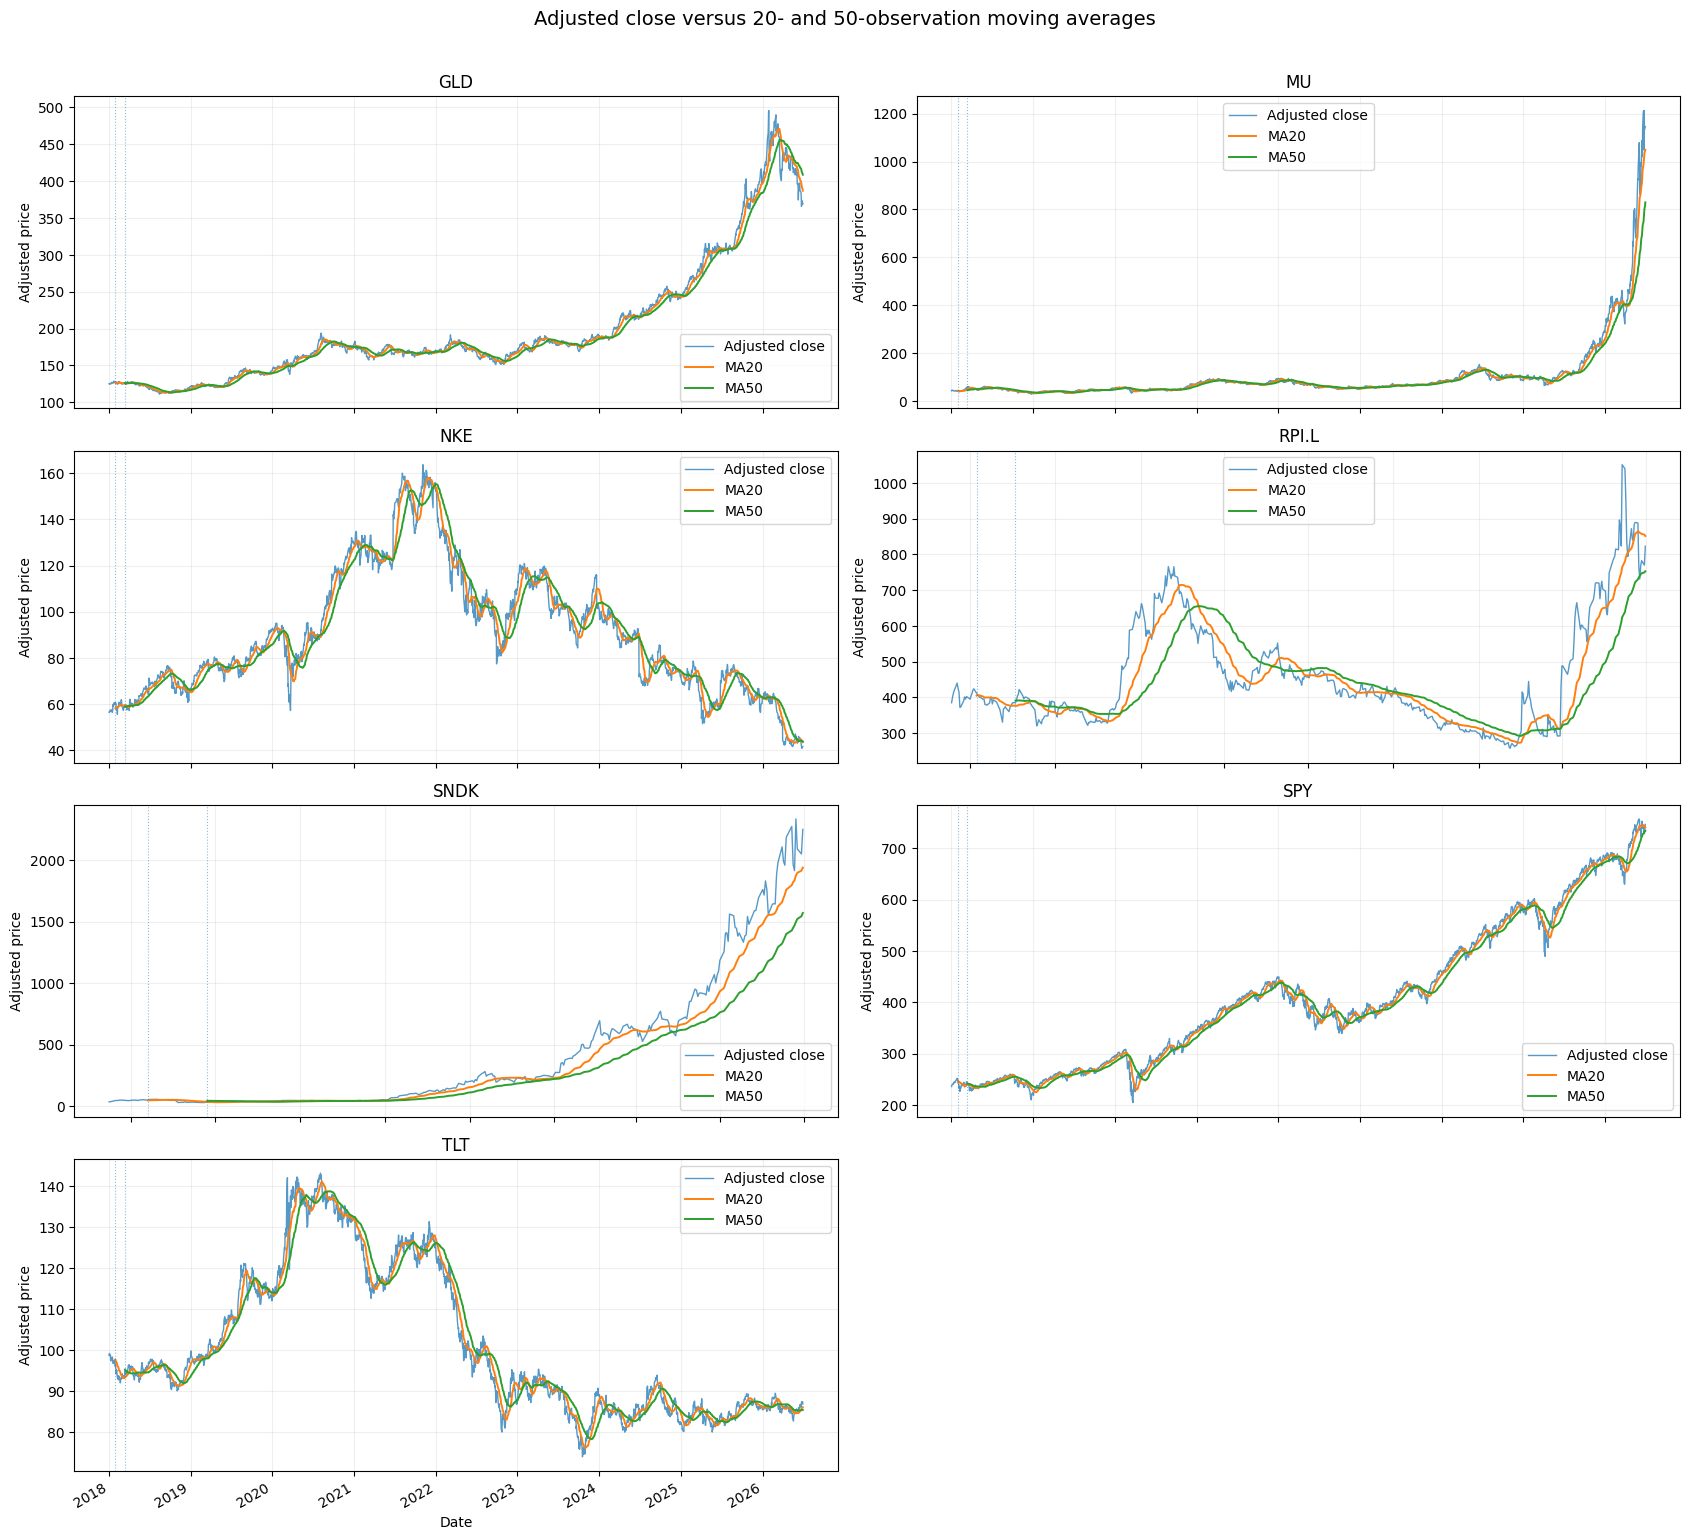

Graph 3:


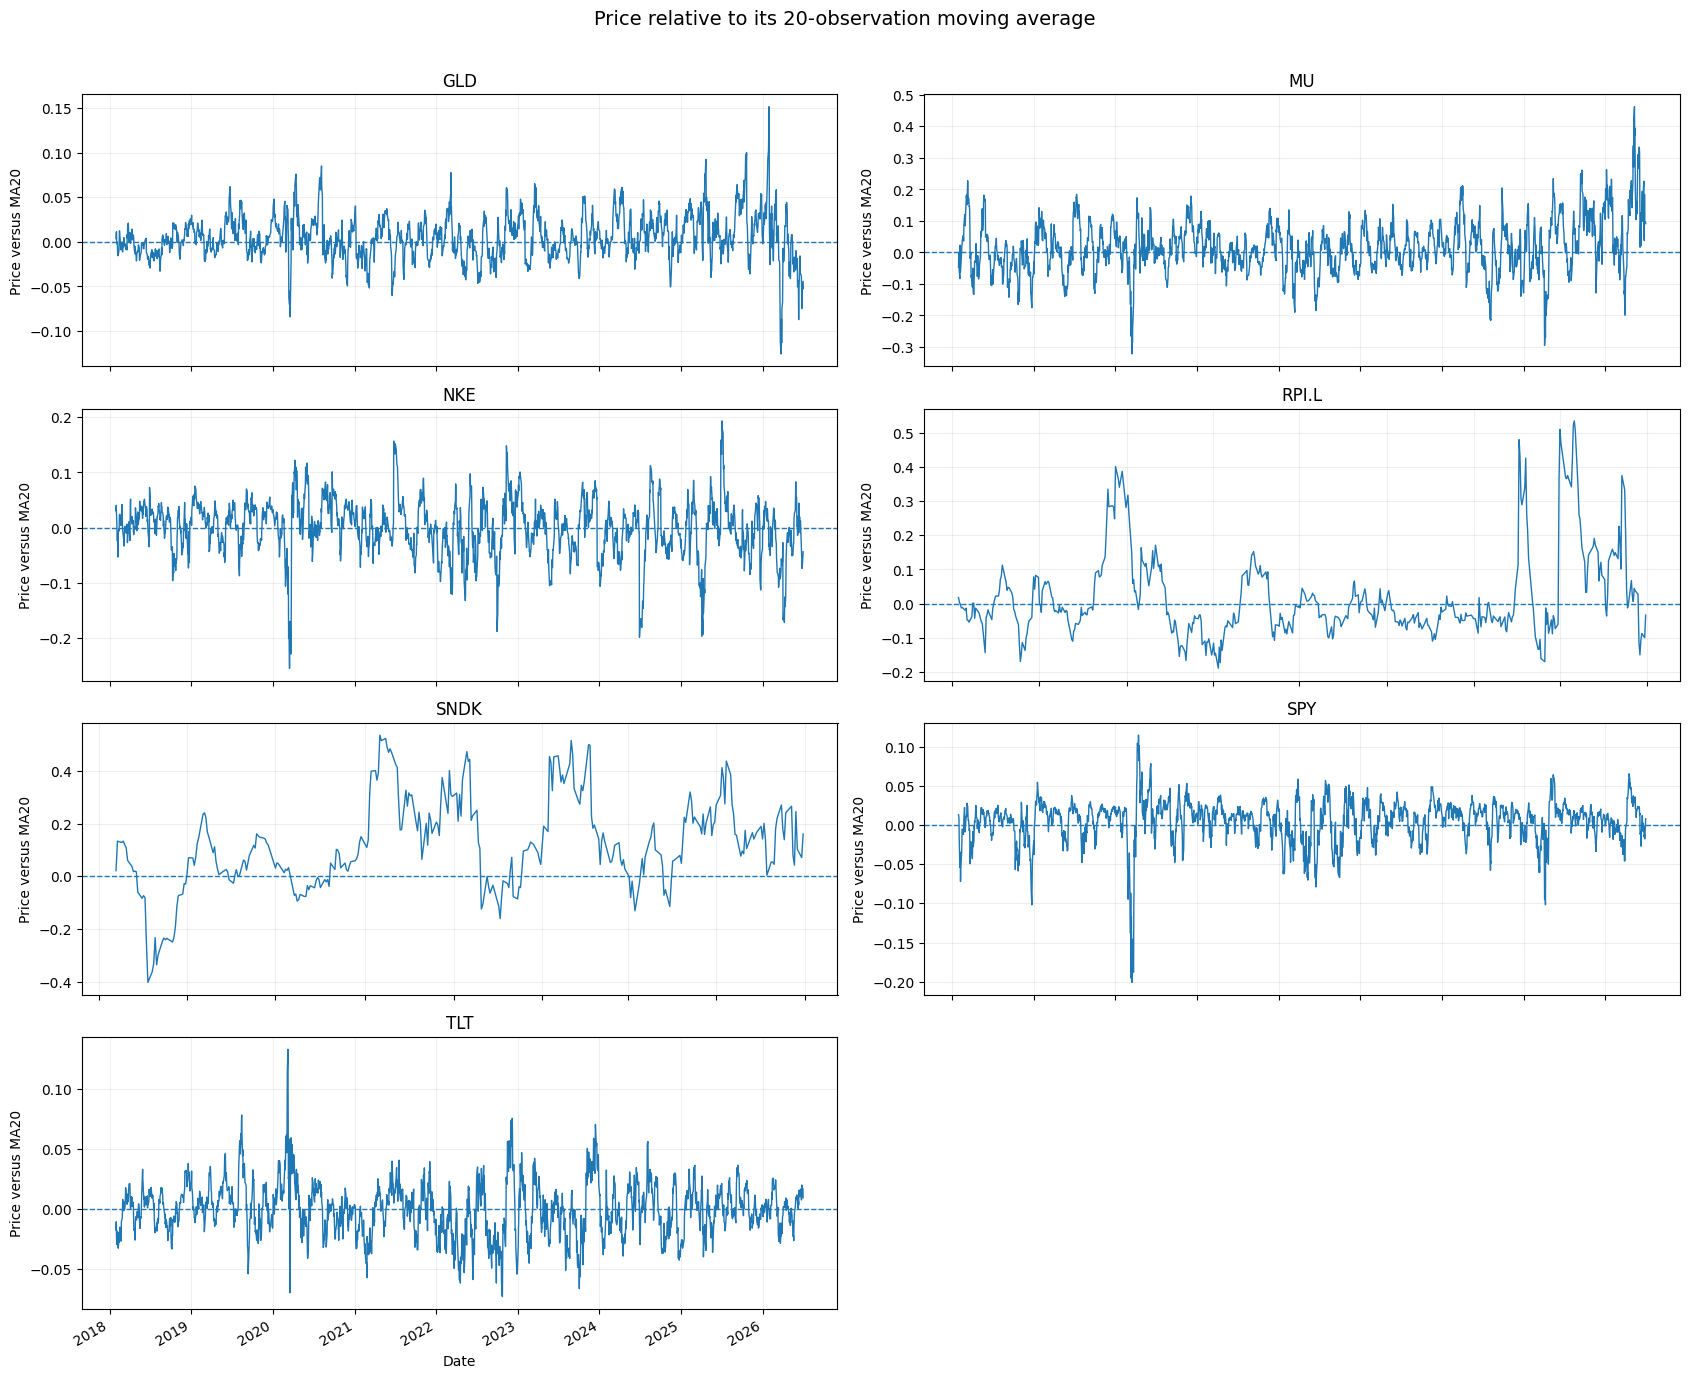

Table 10:


,Ticker,Median |price return|,Median |MA20 return|,Median |MA50 return|,Maximum |MA20 one-row change|,Maximum |MA50 one-row change|,Median |price - MA20| / MA20,Median |price - MA50| / MA50,Longest unchanged MA20 run,Longest unchanged MA50 run,MA20-MA50 crossovers
0,GLD,0.005354,0.001313,0.000961,0.011296,0.005910,0.013854,0.026355,1,0,40
1,MU,0.017793,0.004377,0.002793,0.035095,0.023202,0.048578,0.074542,1,1,40
2,NKE,0.010178,0.002551,0.001844,0.019930,0.009500,0.029538,0.048759,1,0,55
3,RPI.L,0.019317,0.005577,0.003684,0.042295,0.023972,0.054744,0.092601,0,0,11
4,SNDK,0.032609,0.012758,0.013638,0.047505,0.033800,0.127698,0.321958,0,0,3
5,SPY,0.005583,0.001558,0.001060,0.018054,0.006585,0.016783,0.030907,0,0,35
6,TLT,0.005701,0.001250,0.000804,0.009034,0.004854,0.013657,0.020551,0,0,41


Most recent five crossover events per ticker:
Table 11:


,Ticker,Date,Direction,Adjusted close,MA20,MA50,Price vs MA20
35,GLD,2025-07-31,MA20 crossed below MA50,302.959991,307.658502,307.745200,-0.015272
36,GLD,2025-08-05,MA20 crossed above MA50,311.160004,308.284001,308.118600,0.009329
37,GLD,2025-08-19,MA20 crossed below MA50,305.269989,308.310495,308.445399,-0.009862
38,GLD,2025-08-26,MA20 crossed above MA50,312.079987,308.641994,308.404398,0.011139
39,GLD,2026-03-26,MA20 crossed below MA50,400.640015,451.850500,455.193002,-0.113335
75,MU,2025-05-20,MA20 crossed above MA50,97.865746,85.311297,84.361218,0.147160
76,MU,2025-08-06,MA20 crossed below MA50,108.622391,113.000535,113.914637,-0.038744
77,MU,2025-08-29,MA20 crossed above MA50,118.837570,118.140077,118.010648,0.005904
78,MU,2026-03-30,MA20 crossed below MA50,321.799988,401.799965,404.240486,-0.199104
79,MU,2026-04-24,MA20 crossed above MA50,496.720001,418.972003,414.698593,0.185568


In [48]:
# ============================================================
# SECTION: INSPECTING MOVING AVERAGES
# ============================================================

expected_features_df = recalculate_features(feature_df)


# ------------------------------------------------------------
# 1. MA availability and start-position table
# ------------------------------------------------------------

ma_start_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    group = group.sort_values(DATE_COL)

    for feature, window in [
        (MA20_COL, 20),
        (MA50_COL, 50),
    ]:
        actual_position = first_valid_position(group[feature])

        expected_series = expected_features_df.loc[
            group.index,
            feature
        ]

        expected_position = first_valid_position(
            expected_series
        )

        actual_date = (
            group.iloc[actual_position][DATE_COL]
            if actual_position is not None
            else pd.NaT
        )

        expected_date = (
            group.iloc[expected_position][DATE_COL]
            if expected_position is not None
            else pd.NaT
        )

        ma_start_records.append(
            {
                "Ticker": ticker,
                "Feature": feature,
                "Window": window,
                "Ticker observations": len(group),
                "Expected first-valid row": expected_position,
                "Actual first-valid row": actual_position,
                "Expected first-valid date": expected_date,
                "Actual first-valid date": actual_date,
                "Status": (
                    "Pass"
                    if actual_position == expected_position
                    else "Review"
                ),
            }
        )

ma_start_table = pd.DataFrame(ma_start_records)

table_count += 1
print(f"Table {table_count}:")

display(ma_start_table)


# ------------------------------------------------------------
# 2. Adjusted close versus MA20 and MA50
# ------------------------------------------------------------

fig, axes = make_ticker_grid(
    n_items=len(TICKERS_IN_DATA),
    ncols=2,
    figure_width=17,
    row_height=3.8,
)

for axis, ticker in zip(axes, TICKERS_IN_DATA):
    group = (
        feature_df
        .loc[feature_df[TICKER_COL].eq(ticker)]
        .sort_values(DATE_COL)
    )

    axis.plot(
        group[DATE_COL],
        group[ADJ_CLOSE_COL],
        label="Adjusted close",
        linewidth=1.0,
        alpha=0.75,
    )

    axis.plot(
        group[DATE_COL],
        group[MA20_COL],
        label="MA20",
        linewidth=1.4,
    )

    axis.plot(
        group[DATE_COL],
        group[MA50_COL],
        label="MA50",
        linewidth=1.4,
    )

    first_ma20_date = first_valid_date(
        group,
        MA20_COL
    )

    first_ma50_date = first_valid_date(
        group,
        MA50_COL
    )

    if pd.notna(first_ma20_date):
        axis.axvline(
            first_ma20_date,
            linestyle=":",
            linewidth=0.8,
            alpha=0.5,
        )

    if pd.notna(first_ma50_date):
        axis.axvline(
            first_ma50_date,
            linestyle=":",
            linewidth=0.8,
            alpha=0.5,
        )

    axis.set_title(str(ticker))
    axis.set_xlabel("Date")
    axis.set_ylabel("Adjusted price")
    axis.grid(alpha=0.2)
    axis.legend(loc="best")

fig.suptitle(
    "Adjusted close versus 20- and 50-observation moving averages",
    fontsize=14,
    y=1.01,
)

fig.autofmt_xdate()
plt.tight_layout()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()


# ------------------------------------------------------------
# 3. price_vs_ma20 through time
# ------------------------------------------------------------

fig, axes = make_ticker_grid(
    n_items=len(TICKERS_IN_DATA),
    ncols=2,
    figure_width=17,
    row_height=3.4,
)

for axis, ticker in zip(axes, TICKERS_IN_DATA):
    group = (
        feature_df
        .loc[feature_df[TICKER_COL].eq(ticker)]
        .sort_values(DATE_COL)
    )

    axis.plot(
        group[DATE_COL],
        group[PRICE_VS_MA20_COL],
        linewidth=1.0,
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=1.0,
    )

    axis.set_title(str(ticker))
    axis.set_xlabel("Date")
    axis.set_ylabel("Price versus MA20")
    axis.grid(alpha=0.2)

fig.suptitle(
    "Price relative to its 20-observation moving average",
    fontsize=14,
    y=1.01,
)

fig.autofmt_xdate()
plt.tight_layout()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()


# ------------------------------------------------------------
# 4. Responsiveness, smoothness, jumps, and flat sections
# ------------------------------------------------------------

moving_average_diagnostic_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    group = group.sort_values(DATE_COL)

    price_change = group[ADJ_CLOSE_COL].pct_change(
        fill_method=None
    )

    ma20_change = group[MA20_COL].pct_change(
        fill_method=None
    )

    ma50_change = group[MA50_COL].pct_change(
        fill_method=None
    )

    price_distance_ma20 = (
        group[ADJ_CLOSE_COL]
        .div(group[MA20_COL].replace(0, np.nan))
        .sub(1)
        .abs()
    )

    price_distance_ma50 = (
        group[ADJ_CLOSE_COL]
        .div(group[MA50_COL].replace(0, np.nan))
        .sub(1)
        .abs()
    )

    spread = (
        group[MA20_COL]
        - group[MA50_COL]
    )

    spread_sign = np.sign(spread)

    crossover_mask = (
        spread_sign.notna()
        & spread_sign.shift(1).notna()
        & spread_sign.ne(spread_sign.shift(1))
    )

    moving_average_diagnostic_records.append(
        {
            "Ticker": ticker,
            "Median |price return|": finite_numeric(
                price_change.abs()
            ).median(),
            "Median |MA20 return|": finite_numeric(
                ma20_change.abs()
            ).median(),
            "Median |MA50 return|": finite_numeric(
                ma50_change.abs()
            ).median(),
            "Maximum |MA20 one-row change|": finite_numeric(
                ma20_change.abs()
            ).max(),
            "Maximum |MA50 one-row change|": finite_numeric(
                ma50_change.abs()
            ).max(),
            "Median |price - MA20| / MA20": finite_numeric(
                price_distance_ma20
            ).median(),
            "Median |price - MA50| / MA50": finite_numeric(
                price_distance_ma50
            ).median(),
            "Longest unchanged MA20 run": longest_constant_run(
                group[MA20_COL]
            ),
            "Longest unchanged MA50 run": longest_constant_run(
                group[MA50_COL]
            ),
            "MA20-MA50 crossovers": int(crossover_mask.sum()),
        }
    )

moving_average_diagnostics = pd.DataFrame(
    moving_average_diagnostic_records
)

table_count += 1
print(f"Table {table_count}:")

display(moving_average_diagnostics)


# ------------------------------------------------------------
# 5. Crossover event table
# ------------------------------------------------------------

crossover_event_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    group = group.sort_values(DATE_COL).copy()

    group["ma_spread"] = (
        group[MA20_COL]
        - group[MA50_COL]
    )

    group["spread_sign"] = np.sign(
        group["ma_spread"]
    )

    crossover_mask = (
        group["spread_sign"].notna()
        & group["spread_sign"].shift(1).notna()
        & group["spread_sign"].ne(
            group["spread_sign"].shift(1)
        )
    )

    crossover_rows = group.loc[crossover_mask]

    for _, row in crossover_rows.iterrows():
        direction = (
            "MA20 crossed above MA50"
            if row["ma_spread"] > 0
            else "MA20 crossed below MA50"
        )

        crossover_event_records.append(
            {
                "Ticker": ticker,
                "Date": row[DATE_COL],
                "Direction": direction,
                "Adjusted close": row[ADJ_CLOSE_COL],
                "MA20": row[MA20_COL],
                "MA50": row[MA50_COL],
                "Price vs MA20": row[PRICE_VS_MA20_COL],
            }
        )

ma_crossover_events = pd.DataFrame(
    crossover_event_records
)

if ma_crossover_events.empty:
    print("No MA20-MA50 crossovers were found.")
else:
    recent_ma_crossovers = (
        ma_crossover_events
        .sort_values(["Ticker", "Date"])
        .groupby("Ticker", as_index=False)
        .tail(5)
    )

    print("Most recent five crossover events per ticker:")

    table_count += 1
    print(f"Table {table_count}:")

    display(recent_ma_crossovers)

# Inspecting Relative Volume

Graph 4:


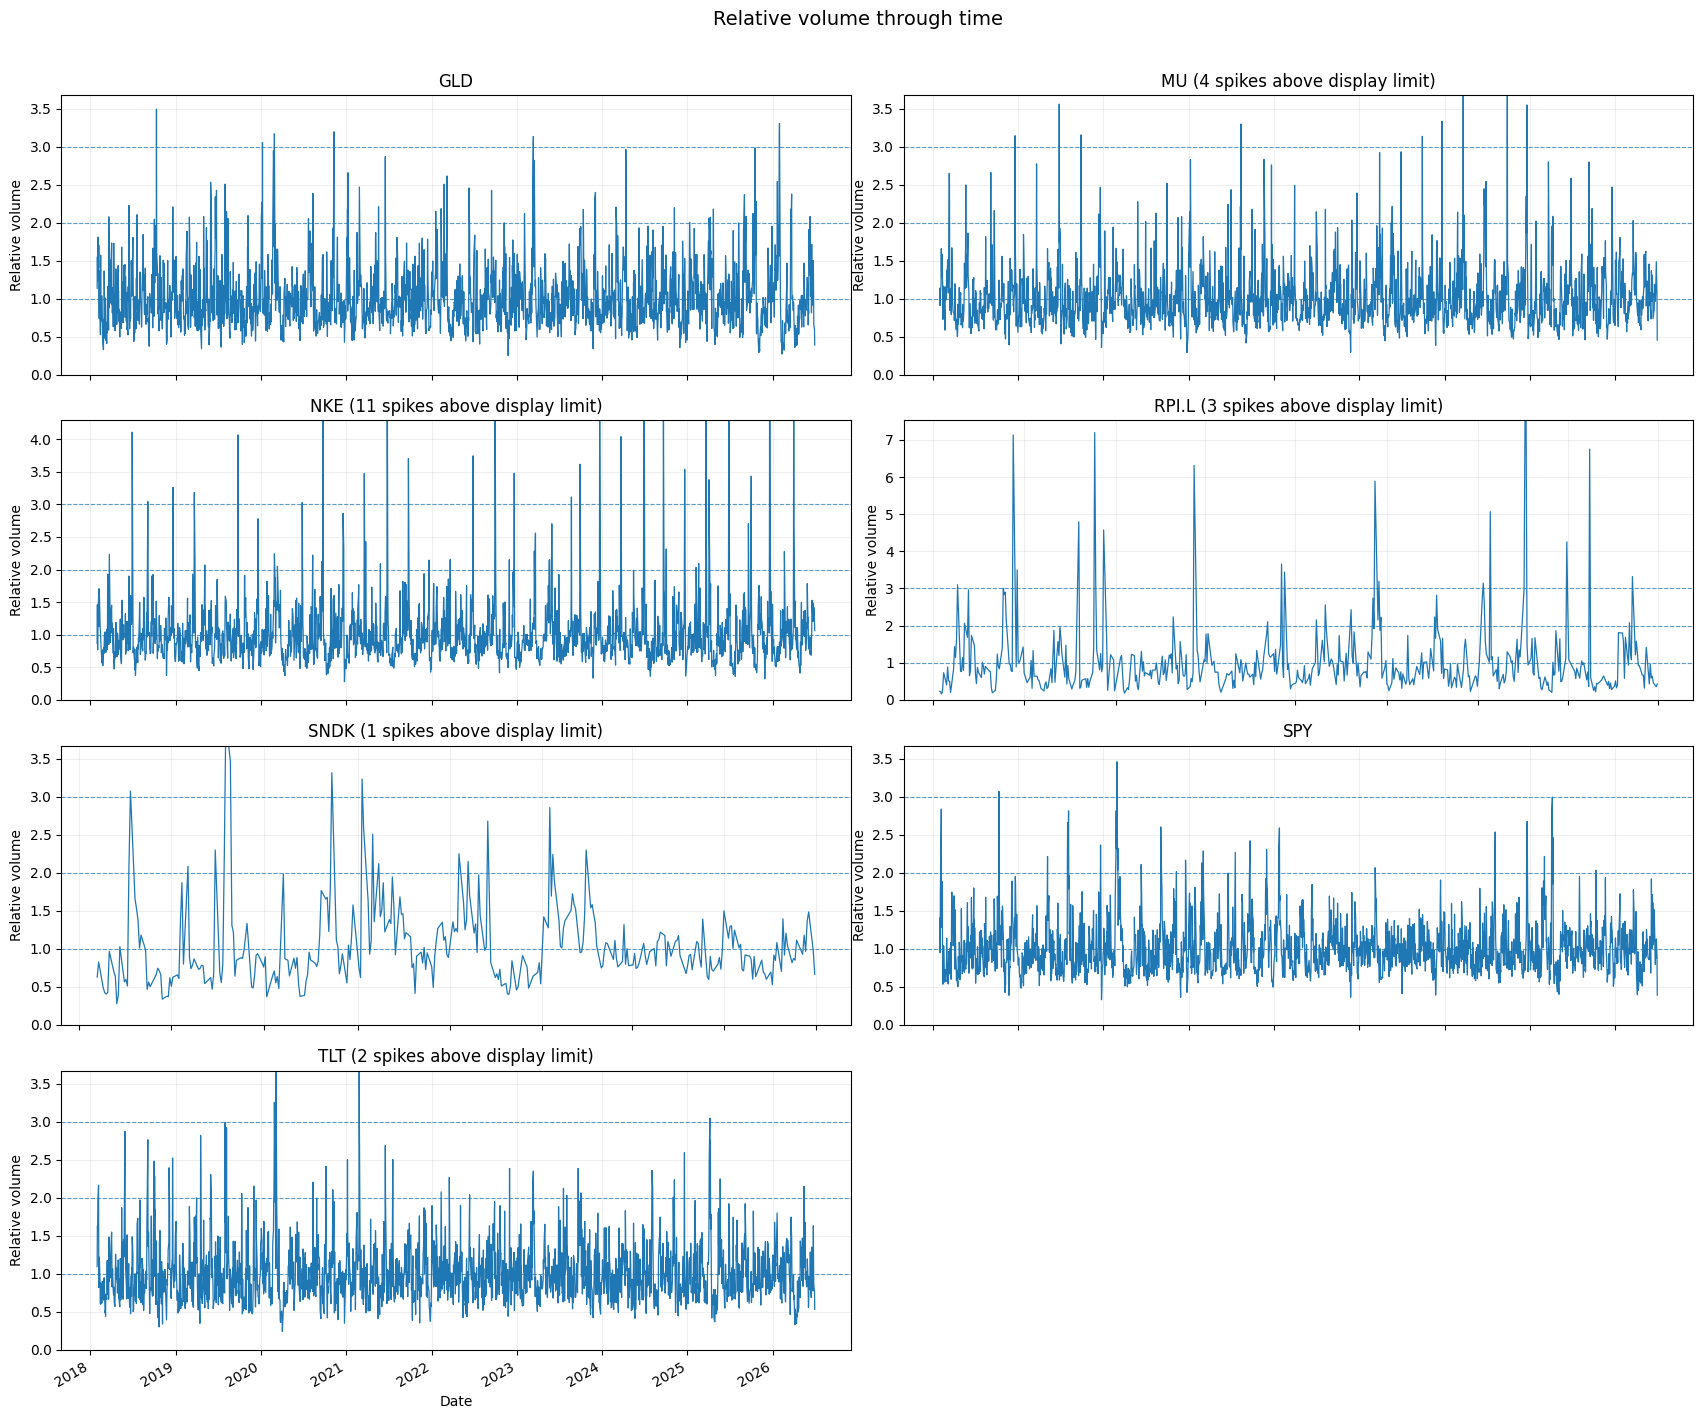

Table 12:


,Ticker,Valid observations,Median,Mean,95th percentile,99th percentile,Maximum,% above 2,% above 3,Skewness
0,GLD,2115,0.918493,1.010768,1.810707,2.429021,3.492790,3.026005,0.330969,1.634136
1,MU,2115,0.917903,1.011139,1.700103,2.538126,3.865706,2.978723,0.425532,2.198283
2,NKE,2115,0.910657,1.018845,1.766921,3.250572,8.157738,3.073286,1.229314,4.565855
3,RPI.L,500,0.759603,1.036663,2.765107,6.318446,7.774821,8.000000,4.000000,3.826739
4,SNDK,326,0.910688,1.040456,2.086685,3.195631,4.021614,5.521472,1.533742,2.081673
5,SPY,2115,0.941352,1.007968,1.652934,2.312471,3.461918,1.843972,0.094563,1.865507
6,TLT,2115,0.939580,1.012337,1.712323,2.395884,3.892315,2.364066,0.189125,1.713828


Graph 5:


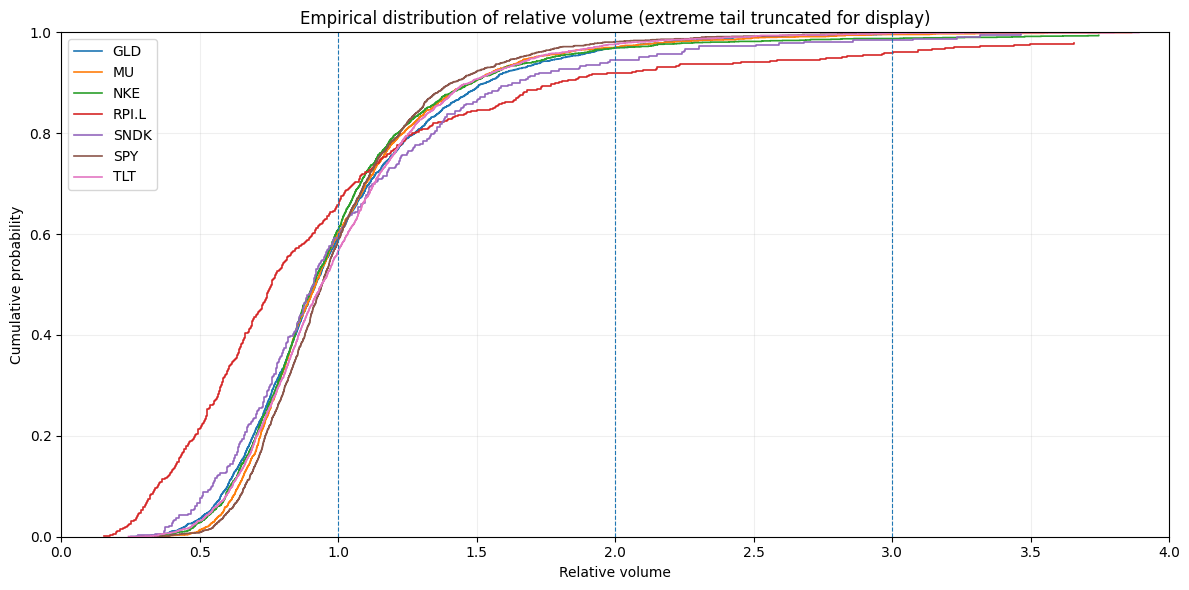

Table 13:


,ticker,date,volume,relative_volume_no_calendar,daily_return_no_calendar,price_vs_ma20_no_calendar,rolling_7d_return_no_calendar,rolling_30d_return_no_calendar,Absolute daily return
0,GLD,2018-10-11,26810900,3.492790,0.025691,0.021154,0.016773,0.013835,0.025691
1,GLD,2026-01-30,86593500,3.305039,-0.102742,0.018581,0.003043,0.123923,0.102742
2,GLD,2020-11-09,29800700,3.195691,-0.044271,-0.019454,-0.001824,-0.009168,0.044271
3,GLD,2020-02-28,42699600,3.167982,-0.036493,-0.011531,-0.022465,0.012556,0.036493
4,GLD,2023-03-13,20554400,3.133226,0.022948,0.040239,0.042189,-0.007588,0.022948
...,...,...,...,...,...,...,...,...,...
65,TLT,2021-02-26,45423300,2.977179,0.033059,-0.023316,-0.018314,-0.061344,0.033059
66,TLT,2019-08-07,32582000,2.925926,0.000357,0.053624,0.066905,0.058454,0.000357
67,TLT,2018-05-29,21668100,2.875878,0.021902,0.032768,0.051888,0.012978,0.021902
68,TLT,2019-04-18,27589400,2.824722,0.005235,-0.009335,-0.008711,0.017436,0.005235


These dates are candidate event dates. External earnings or news data is required before assigning a specific cause.


In [49]:
# ============================================================
# SECTION: INSPECTING RELATIVE VOLUME
# ============================================================

TOP_VOLUME_EVENTS_PER_TICKER = 10
RELATIVE_VOLUME_DISPLAY_QUANTILE = 0.995


# ------------------------------------------------------------
# 1. Relative-volume time series
# ------------------------------------------------------------

fig, axes = make_ticker_grid(
    n_items=len(TICKERS_IN_DATA),
    ncols=2,
    figure_width=17,
    row_height=3.5,
)

for axis, ticker in zip(axes, TICKERS_IN_DATA):
    group = (
        feature_df
        .loc[feature_df[TICKER_COL].eq(ticker)]
        .sort_values(DATE_COL)
    )

    relative_volume = finite_numeric(
        group[RELATIVE_VOLUME_COL]
    )

    display_limit = (
        relative_volume.quantile(
            RELATIVE_VOLUME_DISPLAY_QUANTILE
        )
        if len(relative_volume) > 0
        else 3.5
    )

    display_limit = max(
        3.5,
        float(display_limit)
        if pd.notna(display_limit)
        else 3.5,
    )

    clipped_count = int(
        (
            group[RELATIVE_VOLUME_COL]
            > display_limit
        ).sum()
    )

    axis.plot(
        group[DATE_COL],
        group[RELATIVE_VOLUME_COL],
        linewidth=0.9,
    )

    for reference_value in [1, 2, 3]:
        axis.axhline(
            reference_value,
            linestyle="--",
            linewidth=0.8,
            alpha=0.7,
        )

    axis.set_ylim(
        bottom=0,
        top=display_limit * 1.05,
    )

    title = str(ticker)

    if clipped_count > 0:
        title += f" ({clipped_count} spikes above display limit)"

    axis.set_title(title)
    axis.set_xlabel("Date")
    axis.set_ylabel("Relative volume")
    axis.grid(alpha=0.2)

fig.suptitle(
    "Relative volume through time",
    fontsize=14,
    y=1.01,
)

fig.autofmt_xdate()
plt.tight_layout()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()


# ------------------------------------------------------------
# 2. Relative-volume summary table
# ------------------------------------------------------------

relative_volume_summary_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    values = finite_numeric(
        group[RELATIVE_VOLUME_COL]
    )

    relative_volume_summary_records.append(
        {
            "Ticker": ticker,
            "Valid observations": len(values),
            "Median": values.median(),
            "Mean": values.mean(),
            "95th percentile": values.quantile(0.95),
            "99th percentile": values.quantile(0.99),
            "Maximum": values.max(),
            "% above 2": (
                values.gt(2).mean() * 100
                if len(values) > 0
                else np.nan
            ),
            "% above 3": (
                values.gt(3).mean() * 100
                if len(values) > 0
                else np.nan
            ),
            "Skewness": values.skew(),
        }
    )

relative_volume_summary = pd.DataFrame(
    relative_volume_summary_records
)

table_count += 1
print(f"Table {table_count}:")

display(relative_volume_summary)


# ------------------------------------------------------------
# 3. Relative-volume empirical distribution
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(12, 6))

all_relative_volume = finite_numeric(
    feature_df[RELATIVE_VOLUME_COL]
)

ecdf_display_limit = (
    all_relative_volume.quantile(0.995)
    if len(all_relative_volume) > 0
    else 4
)

ecdf_display_limit = max(
    4,
    float(ecdf_display_limit)
    if pd.notna(ecdf_display_limit)
    else 4,
)

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    x_values, y_values = ecdf_values(
        group[RELATIVE_VOLUME_COL]
    )

    display_mask = x_values <= ecdf_display_limit

    ax.step(
        x_values[display_mask],
        y_values[display_mask],
        where="post",
        label=str(ticker),
        linewidth=1.2,
    )

for reference_value in [1, 2, 3]:
    ax.axvline(
        reference_value,
        linestyle="--",
        linewidth=0.8,
    )

ax.set_xlim(left=0, right=ecdf_display_limit)
ax.set_ylim(0, 1)

ax.set_title(
    "Empirical distribution of relative volume "
    "(extreme tail truncated for display)"
)

ax.set_xlabel("Relative volume")
ax.set_ylabel("Cumulative probability")
ax.grid(alpha=0.2)
ax.legend(loc="best")

plt.tight_layout()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()


# ------------------------------------------------------------
# 4. Largest relative-volume events
# ------------------------------------------------------------

relative_volume_event_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    event_data = group[
        [
            TICKER_COL,
            DATE_COL,
            VOLUME_COL,
            RELATIVE_VOLUME_COL,
            DAILY_RETURN_COL,
            PRICE_VS_MA20_COL,
            ROLLING_7_RETURN_COL,
            ROLLING_30_RETURN_COL,
        ]
    ].copy()

    event_data[RELATIVE_VOLUME_COL] = pd.to_numeric(
        event_data[RELATIVE_VOLUME_COL],
        errors="coerce"
    )

    event_data = event_data.replace(
        [np.inf, -np.inf],
        np.nan
    )

    event_data["Absolute daily return"] = (
        event_data[DAILY_RETURN_COL].abs()
    )

    event_data = (
        event_data
        .dropna(subset=[RELATIVE_VOLUME_COL])
        .nlargest(
            TOP_VOLUME_EVENTS_PER_TICKER,
            RELATIVE_VOLUME_COL
        )
    )

    relative_volume_event_records.append(event_data)

relative_volume_spike_table = pd.concat(
    relative_volume_event_records,
    ignore_index=True
)

relative_volume_spike_table = (
    relative_volume_spike_table
    .sort_values(
        [TICKER_COL, RELATIVE_VOLUME_COL],
        ascending=[True, False]
    )
)

table_count += 1
print(f"Table {table_count}:")

display(relative_volume_spike_table)

print(
    "These dates are candidate event dates. External earnings or news "
    "data is required before assigning a specific cause."
)

# Inspecting Lagged Returns

Table 14:


,Ticker,Date,Current daily return,Expected lag 1,Stored lag 1,Lag 1 absolute error,Expected lag 5,Stored lag 5,Lag 5 absolute error
0,GLD,2018-01-10,0.002405,-0.004628,-0.004628,0.0,-0.002637,-0.002637,0.0
1,GLD,2018-01-11,0.003279,0.002405,0.002405,0.0,0.005127,0.005127,0.0
2,GLD,2022-04-01,-0.006366,0.000388,0.000388,0.0,-0.004095,-0.004095,0.0
3,GLD,2026-06-29,-0.013516,0.011287,0.011287,0.0,-0.006535,-0.006535,0.0
4,GLD,2026-06-30,0.003577,-0.013516,-0.013516,0.0,-0.018903,-0.018903,0.0
5,MU,2018-01-10,0.007912,-0.056641,-0.056641,0.0,0.029998,0.029998,0.0
6,MU,2018-01-11,-0.011314,0.007912,0.007912,0.0,0.042241,0.042241,0.0
7,MU,2022-04-01,-0.021954,-0.016043,-0.016043,0.0,-0.001407,-0.001407,0.0
8,MU,2026-06-29,0.011437,-0.066935,-0.066935,0.0,0.068246,0.068246,0.0
9,MU,2026-06-30,0.000489,0.011437,0.011437,0.0,-0.131759,-0.131759,0.0


Table 15:


,Ticker,Feature,Rows compared,Maximum absolute error,Mean absolute error,NaN-pattern mismatches,Status
0,GLD,lag_1_return_no_calendar,2132,0.0,0.0,0,Pass
1,GLD,lag_5_return_no_calendar,2128,0.0,0.0,0,Pass
2,MU,lag_1_return_no_calendar,2132,0.0,0.0,0,Pass
3,MU,lag_5_return_no_calendar,2128,0.0,0.0,0,Pass
4,NKE,lag_1_return_no_calendar,2132,0.0,0.0,0,Pass
5,NKE,lag_5_return_no_calendar,2128,0.0,0.0,0,Pass
6,RPI.L,lag_1_return_no_calendar,517,0.0,0.0,0,Pass
7,RPI.L,lag_5_return_no_calendar,513,0.0,0.0,0,Pass
8,SNDK,lag_1_return_no_calendar,343,0.0,0.0,0,Pass
9,SNDK,lag_5_return_no_calendar,339,0.0,0.0,0,Pass


Table 16:


,"Corr(lag 1, current return)","Corr(lag 5, current return)","Corr(lag 1, next-day return)","Corr(lag 5, next-day return)"
Ticker,,,,
GLD,-0.022310,0.006581,-0.017207,0.004169
MU,-0.027468,-0.002557,0.011012,-0.038536
NKE,-0.033374,0.005445,0.012334,-0.009272
RPI.L,0.021126,0.058888,0.019722,0.005174
SNDK,-0.045593,-0.006297,-0.113155,-0.038376
SPY,-0.025910,-0.008684,-0.014347,-0.021296
TLT,-0.027608,-0.013934,-0.043736,0.011423


Table 17:


,Lag quantile,Median_next_day_return,Mean_next_day_return,Observations,Ticker,Lag feature
0,1,0.001586,0.001319,427,GLD,lag_1_return_no_calendar
1,2,0.000373,-0.000051,426,GLD,lag_1_return_no_calendar
2,3,0.000361,0.000576,426,GLD,lag_1_return_no_calendar
3,4,0.000512,0.000303,426,GLD,lag_1_return_no_calendar
4,5,0.000755,0.000670,426,GLD,lag_1_return_no_calendar
...,...,...,...,...,...,...
65,1,0.000069,-0.000484,426,TLT,lag_5_return_no_calendar
66,2,-0.000115,0.000188,425,TLT,lag_5_return_no_calendar
67,3,0.000250,-0.000021,425,TLT,lag_5_return_no_calendar
68,4,0.000000,-0.000219,425,TLT,lag_5_return_no_calendar


Graph 6:


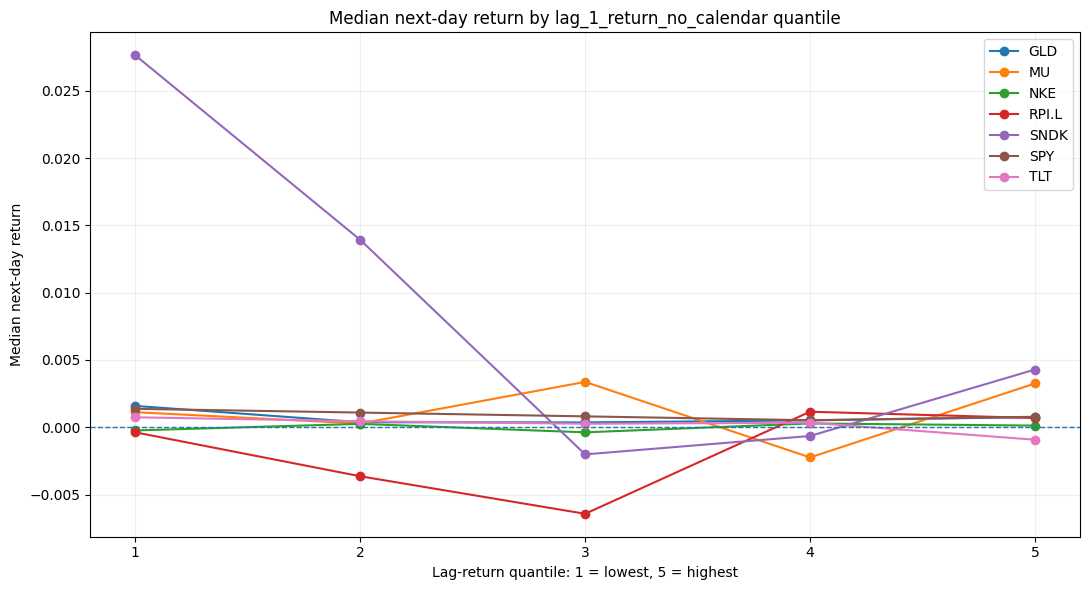

Graph 7:


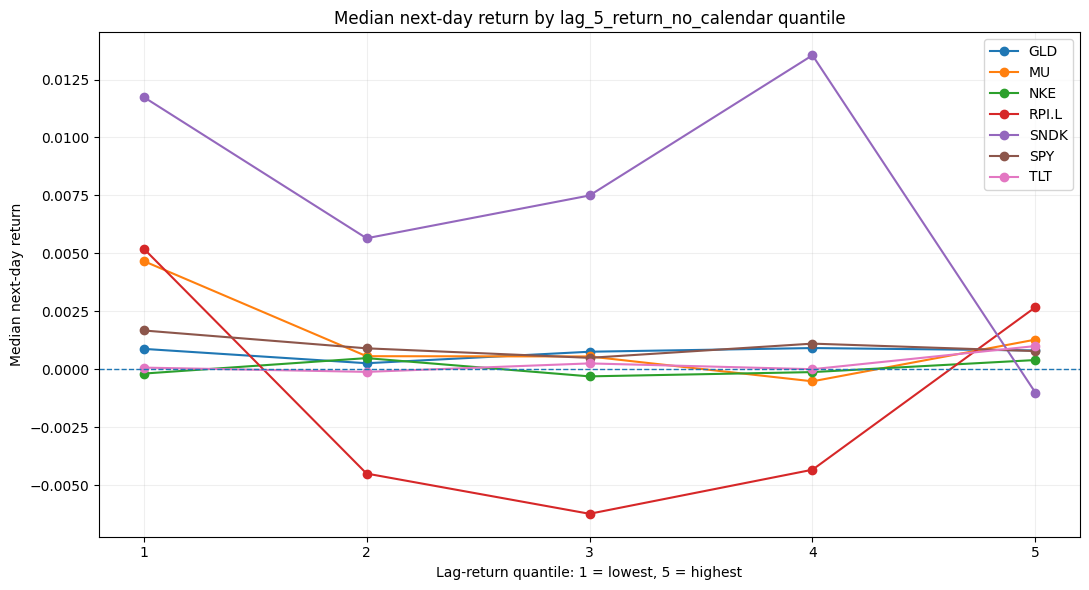

In [50]:
# ============================================================
# SECTION: INSPECTING LAGGED RETURNS
# ============================================================

LAG_QUANTILES = 5


# ------------------------------------------------------------
# 1. Lag-alignment audit table
# ------------------------------------------------------------

lag_alignment_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    group = (
        group
        .sort_values(DATE_COL)
        .copy()
    )

    group["Expected lag 1"] = (
        group[DAILY_RETURN_COL]
        .shift(1)
    )

    group["Expected lag 5"] = (
        group[DAILY_RETURN_COL]
        .shift(5)
    )

    valid_positions = np.flatnonzero(
        (
            group[LAG_1_RETURN_COL].notna()
            & group[LAG_5_RETURN_COL].notna()
        ).to_numpy()
    )

    if len(valid_positions) == 0:
        continue

    candidate_positions = {
        int(valid_positions[0]),
        int(valid_positions[min(1, len(valid_positions) - 1)]),
        int(valid_positions[len(valid_positions) // 2]),
        int(valid_positions[max(len(valid_positions) - 2, 0)]),
        int(valid_positions[-1]),
    }

    for position in sorted(candidate_positions):
        row = group.iloc[position]

        lag_alignment_records.append(
            {
                "Ticker": ticker,
                "Date": row[DATE_COL],
                "Current daily return": row[DAILY_RETURN_COL],
                "Expected lag 1": row["Expected lag 1"],
                "Stored lag 1": row[LAG_1_RETURN_COL],
                "Lag 1 absolute error": abs(
                    row[LAG_1_RETURN_COL]
                    - row["Expected lag 1"]
                ),
                "Expected lag 5": row["Expected lag 5"],
                "Stored lag 5": row[LAG_5_RETURN_COL],
                "Lag 5 absolute error": abs(
                    row[LAG_5_RETURN_COL]
                    - row["Expected lag 5"]
                ),
            }
        )

lag_alignment_audit = pd.DataFrame(
    lag_alignment_records
)

table_count += 1
print(f"Table {table_count}:")

display(lag_alignment_audit)


# ------------------------------------------------------------
# 2. Full lag-alignment error summary
# ------------------------------------------------------------

lag_error_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    group = (
        group
        .sort_values(DATE_COL)
        .copy()
    )

    expected_lag_1 = (
        group[DAILY_RETURN_COL]
        .shift(1)
    )

    expected_lag_5 = (
        group[DAILY_RETURN_COL]
        .shift(5)
    )

    for feature, expected_series in [
        (LAG_1_RETURN_COL, expected_lag_1),
        (LAG_5_RETURN_COL, expected_lag_5),
    ]:
        actual_series = pd.to_numeric(
            group[feature],
            errors="coerce"
        )

        comparison_mask = (
            actual_series.notna()
            & expected_series.notna()
        )

        errors = (
            actual_series[comparison_mask]
            - expected_series[comparison_mask]
        ).abs()

        nan_pattern_mismatch = (
            actual_series.isna()
            ^ expected_series.isna()
        )

        lag_error_records.append(
            {
                "Ticker": ticker,
                "Feature": feature,
                "Rows compared": int(comparison_mask.sum()),
                "Maximum absolute error": errors.max(),
                "Mean absolute error": errors.mean(),
                "NaN-pattern mismatches": int(
                    nan_pattern_mismatch.sum()
                ),
                "Status": (
                    "Pass"
                    if (
                        errors.fillna(0).le(
                            NUMERICAL_ATOL
                        ).all()
                        and not nan_pattern_mismatch.any()
                    )
                    else "Review"
                ),
            }
        )

lag_alignment_summary = pd.DataFrame(
    lag_error_records
)

table_count += 1
print(f"Table {table_count}:")

display(lag_alignment_summary)


# ------------------------------------------------------------
# 3. Spearman lag relationship matrix
# ------------------------------------------------------------

lag_correlation_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    clean_group = (
        group[
            [
                DAILY_RETURN_COL,
                LAG_1_RETURN_COL,
                LAG_5_RETURN_COL,
                TARGET_RETURN_COL,
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
    )

    lag_correlation_records.append(
        {
            "Ticker": ticker,
            "Corr(lag 1, current return)": (
                clean_group[LAG_1_RETURN_COL]
                .corr(
                    clean_group[DAILY_RETURN_COL],
                    method="spearman"
                )
            ),
            "Corr(lag 5, current return)": (
                clean_group[LAG_5_RETURN_COL]
                .corr(
                    clean_group[DAILY_RETURN_COL],
                    method="spearman"
                )
            ),
            "Corr(lag 1, next-day return)": (
                clean_group[LAG_1_RETURN_COL]
                .corr(
                    clean_group[TARGET_RETURN_COL],
                    method="spearman"
                )
            ),
            "Corr(lag 5, next-day return)": (
                clean_group[LAG_5_RETURN_COL]
                .corr(
                    clean_group[TARGET_RETURN_COL],
                    method="spearman"
                )
            ),
        }
    )

lag_relationship_matrix = pd.DataFrame(
    lag_correlation_records
).set_index("Ticker")

table_count += 1
print(f"Table {table_count}:")

display(lag_relationship_matrix)


# ------------------------------------------------------------
# 4. Lag-quantile response tables
# ------------------------------------------------------------

quantile_response_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    for lag_feature in [
        LAG_1_RETURN_COL,
        LAG_5_RETURN_COL,
    ]:
        clean_group = (
            group[
                [
                    lag_feature,
                    TARGET_RETURN_COL,
                ]
            ]
            .replace([np.inf, -np.inf], np.nan)
            .dropna()
            .copy()
        )

        if len(clean_group) < LAG_QUANTILES:
            continue

        ranked_values = clean_group[
            lag_feature
        ].rank(method="first")

        clean_group["Lag quantile"] = (
            pd.qcut(
                ranked_values,
                q=LAG_QUANTILES,
                labels=False
            )
            + 1
        )

        quantile_summary = (
            clean_group
            .groupby("Lag quantile", as_index=False)
            .agg(
                Median_next_day_return=(
                    TARGET_RETURN_COL,
                    "median"
                ),
                Mean_next_day_return=(
                    TARGET_RETURN_COL,
                    "mean"
                ),
                Observations=(
                    TARGET_RETURN_COL,
                    "size"
                ),
            )
        )

        quantile_summary["Ticker"] = ticker
        quantile_summary["Lag feature"] = lag_feature

        quantile_response_records.append(
            quantile_summary
        )

lag_quantile_response = pd.concat(
    quantile_response_records,
    ignore_index=True
)

table_count += 1
print(f"Table {table_count}:")

display(lag_quantile_response)


# ------------------------------------------------------------
# 5. Plot next-day return by lag quantile
# ------------------------------------------------------------

for lag_feature in [
    LAG_1_RETURN_COL,
    LAG_5_RETURN_COL,
]:
    plot_data = lag_quantile_response.loc[
        lag_quantile_response[
            "Lag feature"
        ].eq(lag_feature)
    ]

    fig, ax = plt.subplots(figsize=(11, 6))

    for ticker, ticker_data in plot_data.groupby(
        "Ticker",
        sort=False
    ):
        ticker_data = ticker_data.sort_values(
            "Lag quantile"
        )

        ax.plot(
            ticker_data["Lag quantile"],
            ticker_data["Median_next_day_return"],
            marker="o",
            label=str(ticker),
        )

    ax.axhline(
        0,
        linestyle="--",
        linewidth=1,
    )

    ax.set_xticks(
        range(1, LAG_QUANTILES + 1)
    )

    ax.set_title(
        f"Median next-day return by {lag_feature} quantile"
    )

    ax.set_xlabel(
        "Lag-return quantile: 1 = lowest, 5 = highest"
    )

    ax.set_ylabel("Median next-day return")
    ax.grid(alpha=0.2)
    ax.legend(loc="best")

    plt.tight_layout()

    graph_count += 1
    print(f"Graph {graph_count}:")

    plt.show()

# Inspecting Rolling Returns

Graph 8:


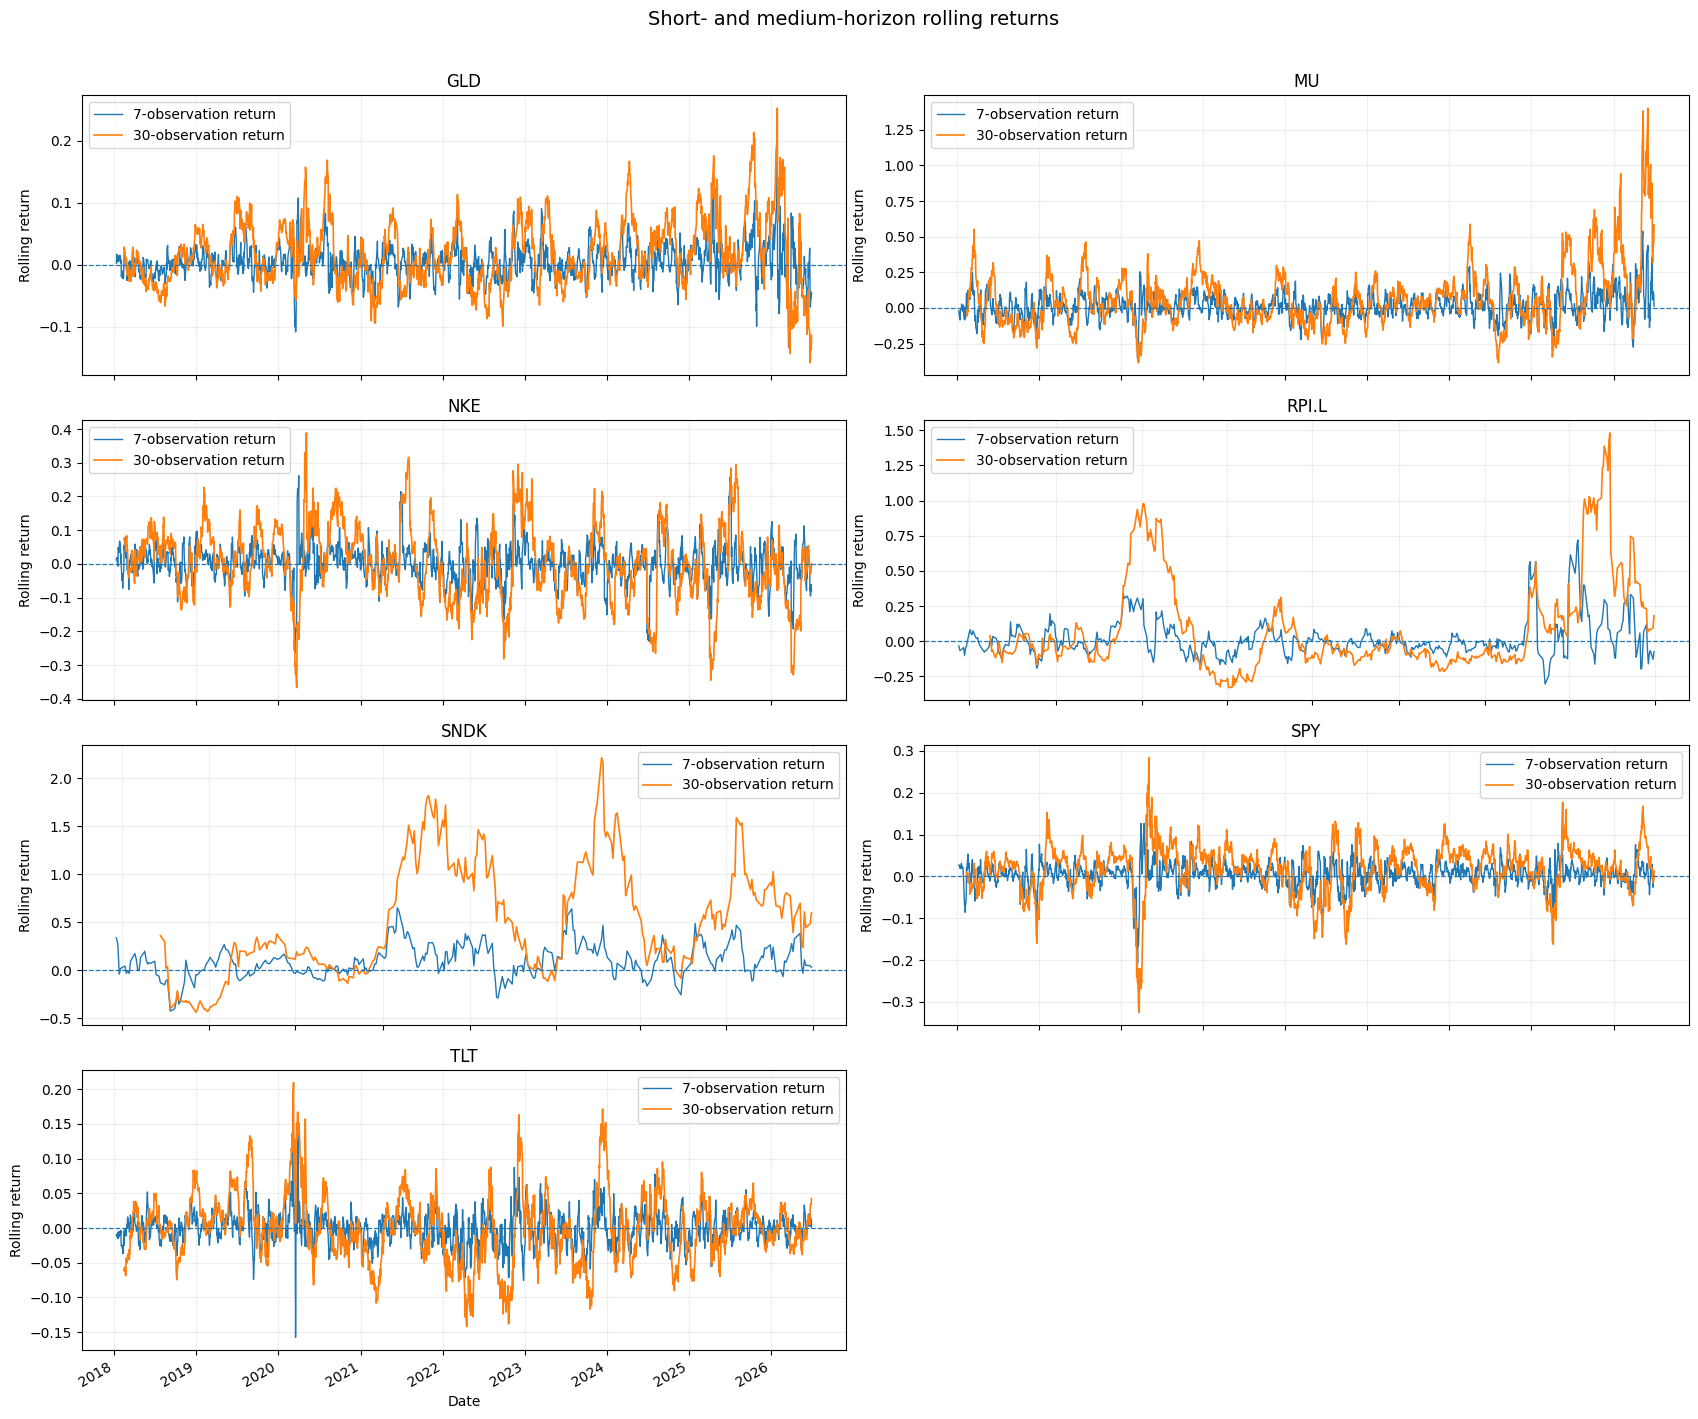

Table 18:


,Ticker,Feature,Ticker rows,Valid rows,Missing rows,Valid %,First valid date
0,GLD,rolling_7d_return_no_calendar,2134,2127,7,99.671978,2018-01-11
1,GLD,rolling_30d_return_no_calendar,2134,2104,30,98.594189,2018-02-14
2,MU,rolling_7d_return_no_calendar,2134,2127,7,99.671978,2018-01-11
3,MU,rolling_30d_return_no_calendar,2134,2104,30,98.594189,2018-02-14
4,NKE,rolling_7d_return_no_calendar,2134,2127,7,99.671978,2018-01-11
5,NKE,rolling_30d_return_no_calendar,2134,2104,30,98.594189,2018-02-14
6,RPI.L,rolling_7d_return_no_calendar,519,512,7,98.651252,2024-06-20
7,RPI.L,rolling_30d_return_no_calendar,519,489,30,94.219653,2024-07-23
8,SNDK,rolling_7d_return_no_calendar,345,338,7,97.971014,2025-02-25
9,SNDK,rolling_30d_return_no_calendar,345,315,30,91.304348,2025-03-28


Graph 9:


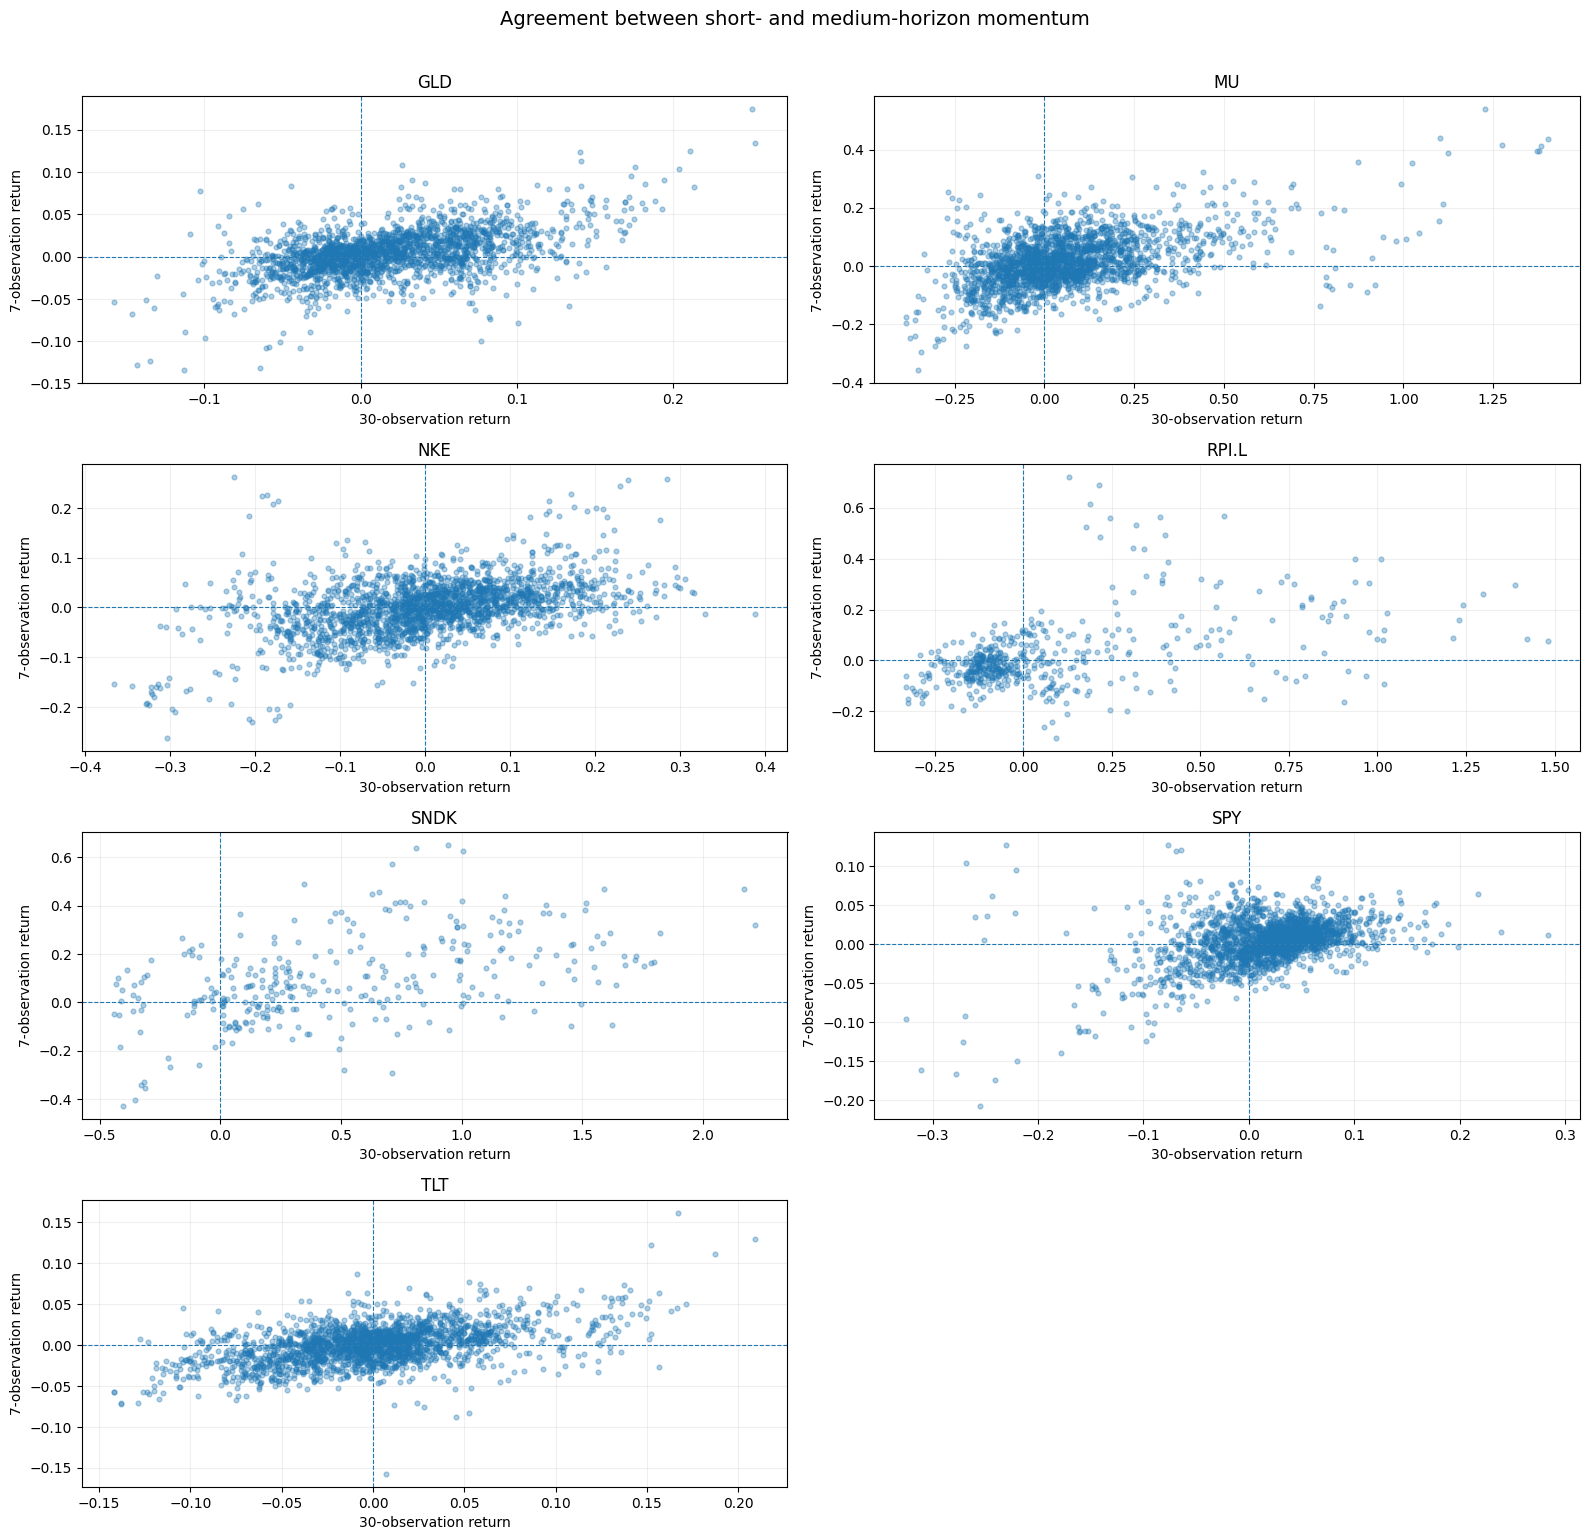

Table 19:


,Observations,Both positive %,Short positive / long negative %,Short negative / long positive %,Both negative %
Ticker,,,,,
GLD,2104,40.494297,16.349810,17.633080,25.522814
MU,2104,38.117871,16.159696,19.866920,25.855513
NKE,2104,34.648289,17.062738,15.969582,32.319392
RPI.L,489,26.584867,17.586912,16.155419,39.672802
SNDK,315,61.587302,9.206349,22.539683,6.666667
SPY,2104,49.382129,12.975285,19.058935,18.583650
TLT,2104,32.081749,19.724335,16.112167,32.081749


In [51]:
# ============================================================
# SECTION: INSPECTING ROLLING RETURNS
# ============================================================

MAX_SCATTER_POINTS_PER_TICKER = 3000


# ------------------------------------------------------------
# 1. Rolling-return time series
# ------------------------------------------------------------

fig, axes = make_ticker_grid(
    n_items=len(TICKERS_IN_DATA),
    ncols=2,
    figure_width=17,
    row_height=3.5,
)

for axis, ticker in zip(axes, TICKERS_IN_DATA):
    group = (
        feature_df
        .loc[feature_df[TICKER_COL].eq(ticker)]
        .sort_values(DATE_COL)
    )

    axis.plot(
        group[DATE_COL],
        group[ROLLING_7_RETURN_COL],
        label="7-observation return",
        linewidth=1.0,
    )

    axis.plot(
        group[DATE_COL],
        group[ROLLING_30_RETURN_COL],
        label="30-observation return",
        linewidth=1.2,
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=0.9,
    )

    axis.set_title(str(ticker))
    axis.set_xlabel("Date")
    axis.set_ylabel("Rolling return")
    axis.grid(alpha=0.2)
    axis.legend(loc="best")

fig.suptitle(
    "Short- and medium-horizon rolling returns",
    fontsize=14,
    y=1.01,
)

fig.autofmt_xdate()
plt.tight_layout()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()


# ------------------------------------------------------------
# 2. Rolling-return availability table
# ------------------------------------------------------------

rolling_return_availability_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    group = group.sort_values(DATE_COL)

    for feature in [
        ROLLING_7_RETURN_COL,
        ROLLING_30_RETURN_COL,
    ]:
        valid_count = int(
            group[feature].notna().sum()
        )

        rolling_return_availability_records.append(
            {
                "Ticker": ticker,
                "Feature": feature,
                "Ticker rows": len(group),
                "Valid rows": valid_count,
                "Missing rows": int(
                    group[feature].isna().sum()
                ),
                "Valid %": (
                    valid_count / len(group) * 100
                    if len(group) > 0
                    else np.nan
                ),
                "First valid date": first_valid_date(
                    group,
                    feature
                ),
            }
        )

rolling_return_availability = pd.DataFrame(
    rolling_return_availability_records
)

table_count += 1
print(f"Table {table_count}:")

display(rolling_return_availability)


# ------------------------------------------------------------
# 3. Rolling 30 versus rolling 7 return
# ------------------------------------------------------------

fig, axes = make_ticker_grid(
    n_items=len(TICKERS_IN_DATA),
    ncols=2,
    figure_width=16,
    row_height=3.8,
)

for axis, ticker in zip(axes, TICKERS_IN_DATA):
    group = (
        feature_df
        .loc[
            feature_df[TICKER_COL].eq(ticker),
            [
                ROLLING_7_RETURN_COL,
                ROLLING_30_RETURN_COL,
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    if len(group) > MAX_SCATTER_POINTS_PER_TICKER:
        group = group.sample(
            MAX_SCATTER_POINTS_PER_TICKER,
            random_state=42
        )

    axis.scatter(
        group[ROLLING_30_RETURN_COL],
        group[ROLLING_7_RETURN_COL],
        alpha=0.35,
        s=12,
    )

    axis.axhline(
        0,
        linestyle="--",
        linewidth=0.8,
    )

    axis.axvline(
        0,
        linestyle="--",
        linewidth=0.8,
    )

    axis.set_title(str(ticker))
    axis.set_xlabel("30-observation return")
    axis.set_ylabel("7-observation return")
    axis.grid(alpha=0.2)

fig.suptitle(
    "Agreement between short- and medium-horizon momentum",
    fontsize=14,
    y=1.01,
)

plt.tight_layout()

graph_count += 1
print(f"Graph {graph_count}:")

plt.show()


# ------------------------------------------------------------
# 4. Rolling-return regime matrix
# ------------------------------------------------------------

rolling_regime_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    clean_group = (
        group[
            [
                ROLLING_7_RETURN_COL,
                ROLLING_30_RETURN_COL,
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
        .dropna()
    )

    total = len(clean_group)

    if total == 0:
        continue

    both_positive = (
        clean_group[ROLLING_7_RETURN_COL].gt(0)
        & clean_group[ROLLING_30_RETURN_COL].gt(0)
    )

    short_positive_long_negative = (
        clean_group[ROLLING_7_RETURN_COL].gt(0)
        & clean_group[ROLLING_30_RETURN_COL].le(0)
    )

    short_negative_long_positive = (
        clean_group[ROLLING_7_RETURN_COL].le(0)
        & clean_group[ROLLING_30_RETURN_COL].gt(0)
    )

    both_negative = (
        clean_group[ROLLING_7_RETURN_COL].le(0)
        & clean_group[ROLLING_30_RETURN_COL].le(0)
    )

    rolling_regime_records.append(
        {
            "Ticker": ticker,
            "Observations": total,
            "Both positive %": (
                both_positive.mean() * 100
            ),
            "Short positive / long negative %": (
                short_positive_long_negative.mean() * 100
            ),
            "Short negative / long positive %": (
                short_negative_long_positive.mean() * 100
            ),
            "Both negative %": (
                both_negative.mean() * 100
            ),
        }
    )

rolling_return_regime_matrix = pd.DataFrame(
    rolling_regime_records
).set_index("Ticker")

table_count += 1
print(f"Table {table_count}:")

display(rolling_return_regime_matrix)

# Inspecting Feature Distributions

Table 20:


,Ticker,Feature,Count,Missing %,Mean,Median,Std,P1,P5,P25,P75,P95,P99,Minimum,Maximum,Skewness,IQR,IQR outlier %
0,GLD,daily_return_no_calendar,2133,0.046860,0.000564,0.000619,0.010588,-0.030544,-0.016204,-0.004506,0.005917,0.016574,0.027924,-0.102742,0.063587,-0.636367,0.010423,5.157056
1,GLD,log_return_no_calendar,2133,0.046860,0.000508,0.000618,0.010624,-0.031020,-0.016337,-0.004516,0.005899,0.016438,0.027541,-0.108412,0.061647,-0.784636,0.010415,5.157056
2,GLD,lag_1_return_no_calendar,2132,0.093721,0.000563,0.000618,0.010591,-0.030545,-0.016207,-0.004513,0.005918,0.016576,0.027927,-0.102742,0.063587,-0.635864,0.010430,5.112570
3,GLD,lag_5_return_no_calendar,2128,0.281162,0.000575,0.000618,0.010571,-0.030546,-0.016175,-0.004505,0.005895,0.016583,0.027939,-0.102742,0.063587,-0.632071,0.010400,5.122180
4,GLD,rolling_7d_return_no_calendar,2127,0.328022,0.003964,0.003364,0.027059,-0.064313,-0.037522,-0.011035,0.018913,0.047585,0.079971,-0.134596,0.173918,0.056040,0.029947,3.573108
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,TLT,rolling_7d_return_no_calendar,2127,0.328022,-0.000136,0.000454,0.023448,-0.055779,-0.037476,-0.015023,0.013671,0.036915,0.060525,-0.157277,0.161759,0.221898,0.028694,2.209685
59,TLT,rolling_30d_return_no_calendar,2104,1.405811,-0.000531,-0.001419,0.049187,-0.113447,-0.079761,-0.031071,0.025429,0.083289,0.136218,-0.141942,0.209374,0.354058,0.056500,3.754753
60,TLT,price_vs_ma20_no_calendar,2115,0.890347,-0.000428,-0.000054,0.021692,-0.049851,-0.035353,-0.014470,0.013102,0.033887,0.056539,-0.073410,0.132958,0.258235,0.027572,1.749409
61,TLT,rolling_30d_volatility_no_calendar,2104,1.405811,0.009034,0.008441,0.003811,0.004519,0.005089,0.006481,0.010739,0.014074,0.030690,0.004239,0.032577,2.909008,0.004258,1.758555


Table 21:
Skewness matrix:


Feature,daily_return_no_calendar,drawdown_no_calendar,lag_1_return_no_calendar,lag_5_return_no_calendar,log_return_no_calendar,price_vs_ma20_no_calendar,rolling_30d_return_no_calendar,rolling_30d_volatility_no_calendar,rolling_7d_return_no_calendar
Ticker,,,,,,,,,
GLD,-0.636367,-0.654852,-0.635864,-0.632071,-0.784636,0.181234,0.487569,2.240710,0.056040
MU,0.175578,0.016540,0.175469,0.137455,-0.103749,0.412275,1.794362,1.572703,0.499028
NKE,-0.268748,-0.325927,-0.268627,-0.269832,-0.765037,-0.568106,-0.093633,1.529691,-0.031942
RPI.L,3.267675,-0.047801,3.286028,3.293918,2.255113,1.719304,1.760955,1.668050,1.926246
SNDK,0.345475,-0.796961,0.352526,0.294087,-0.072830,0.088993,0.522742,-0.532970,0.264177
SPY,-0.294439,-1.443045,-0.293693,-0.293888,-0.568146,-1.669693,-1.040284,3.387862,-1.044103
TLT,0.161246,0.079468,0.160441,0.161311,0.059846,0.258235,0.354058,2.909008,0.221898


Table 22:
Standard-deviation matrix:


Feature,daily_return_no_calendar,drawdown_no_calendar,lag_1_return_no_calendar,lag_5_return_no_calendar,log_return_no_calendar,price_vs_ma20_no_calendar,rolling_30d_return_no_calendar,rolling_30d_volatility_no_calendar,rolling_7d_return_no_calendar
Ticker,,,,,,,,,
GLD,0.010588,0.054836,0.010591,0.010571,0.010624,0.024491,0.053370,0.004322,0.027059
MU,0.033101,0.141123,0.033109,0.032933,0.033041,0.081547,0.210556,0.010856,0.088401
NKE,0.021387,0.234888,0.021392,0.021401,0.021519,0.050052,0.109239,0.008353,0.054697
RPI.L,0.047394,0.197694,0.047350,0.047435,0.044606,0.125090,0.330730,0.022934,0.134275
SNDK,0.064327,0.127731,0.064263,0.063277,0.063334,0.172531,0.570279,0.018103,0.172502
SPY,0.012091,0.059723,0.012093,0.012098,0.012118,0.026960,0.056789,0.006395,0.028589
TLT,0.009738,0.166375,0.009740,0.009744,0.009734,0.021692,0.049187,0.003811,0.023448


Table 23:
IQR-outlier percentage matrix:


Feature,daily_return_no_calendar,drawdown_no_calendar,lag_1_return_no_calendar,lag_5_return_no_calendar,log_return_no_calendar,price_vs_ma20_no_calendar,rolling_30d_return_no_calendar,rolling_30d_volatility_no_calendar,rolling_7d_return_no_calendar
Ticker,,,,,,,,,
GLD,5.157056,0.281162,5.112570,5.122180,5.157056,2.600473,1.425856,7.889734,3.573108
MU,4.031880,0.000000,4.033771,3.994361,4.078762,2.742317,4.420152,3.897338,2.773860
NKE,4.735115,0.000000,4.737336,4.746241,4.547586,3.120567,1.901141,4.372624,3.902210
RPI.L,5.405405,0.000000,5.609284,5.653021,5.405405,8.000000,9.406953,15.337423,7.226562
SNDK,5.813953,0.000000,6.122449,5.899705,5.813953,2.147239,0.000000,0.000000,2.366864
SPY,6.000938,4.545455,6.003752,6.015038,6.047820,3.971631,4.134981,3.802281,4.748472
TLT,2.578528,0.000000,2.579737,2.584586,2.531646,1.749409,3.754753,1.758555,2.209685


Graph 10:


C:\Users\maxan\AppData\Local\Temp\ipykernel_6664\1500193687.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\maxan\AppData\Local\Temp\ipykernel_6664\1500193687.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\maxan\AppData\Local\Temp\ipykernel_6664\1500193687.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\maxan\AppData\Local\Temp\ipykernel_6664\1500193687.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax

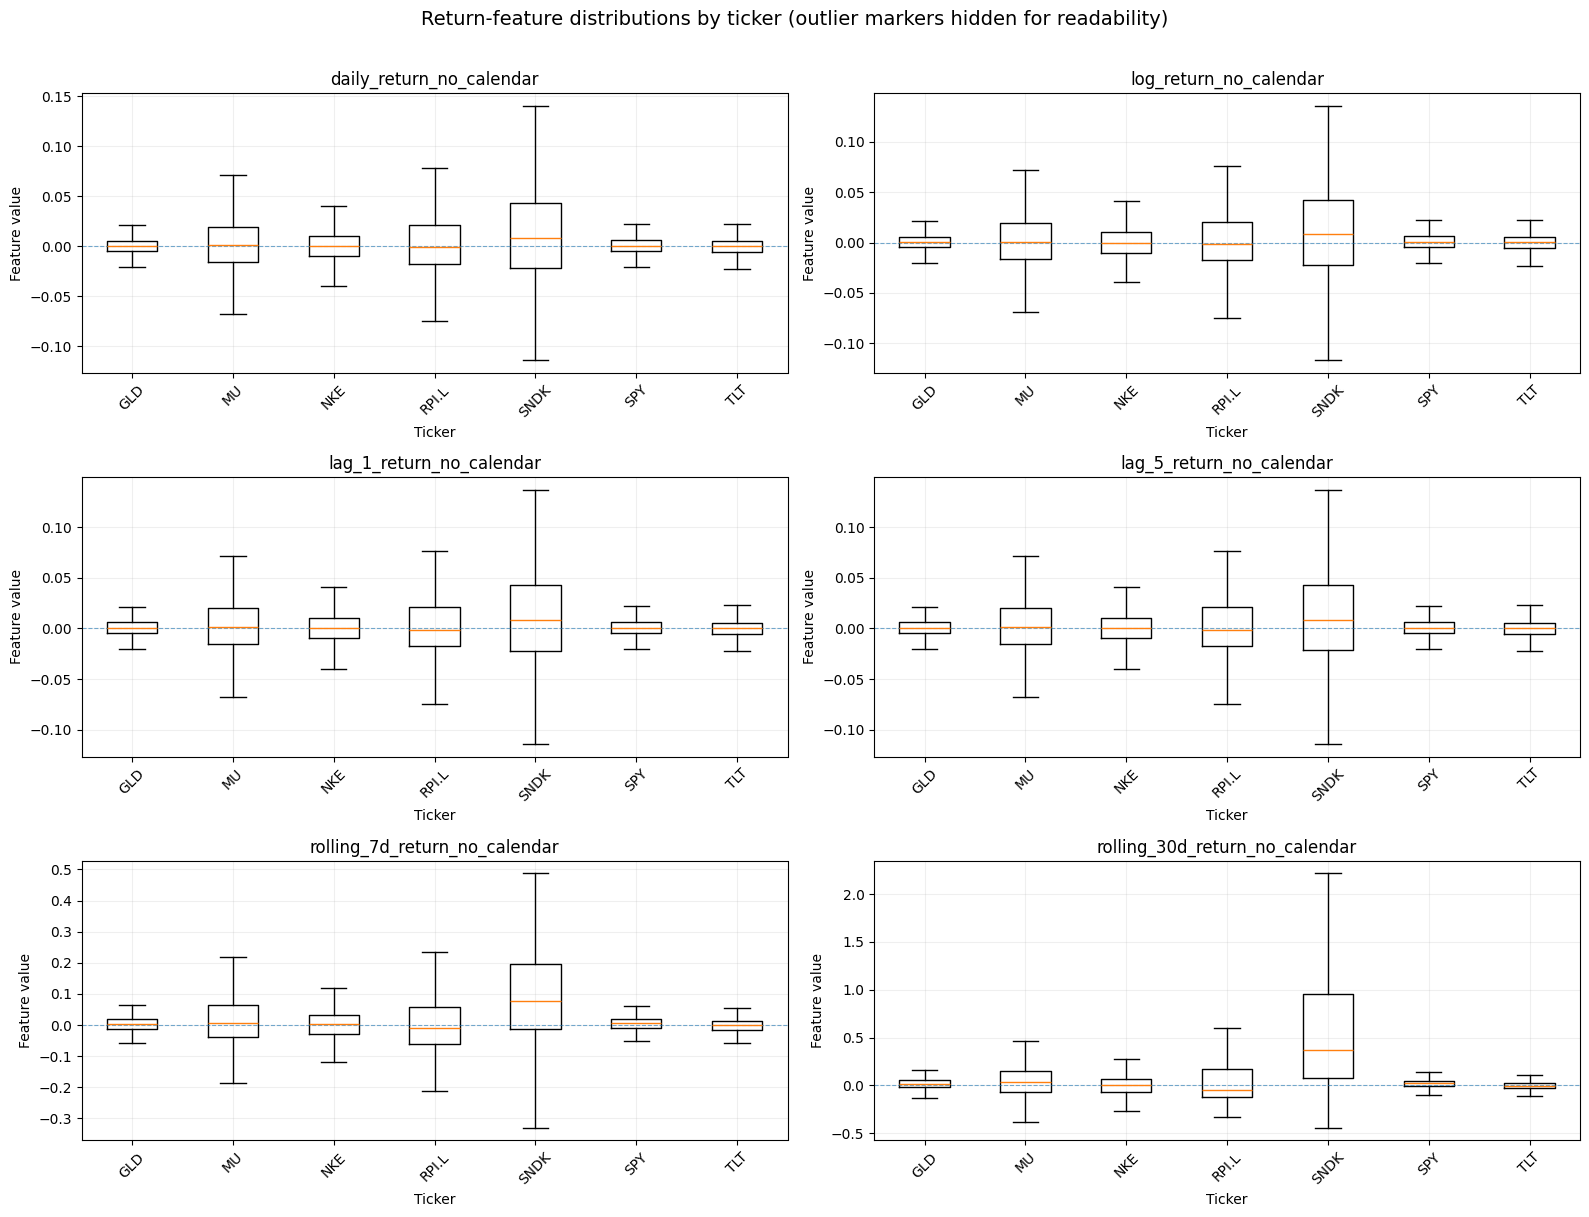

Graph 11:


C:\Users\maxan\AppData\Local\Temp\ipykernel_6664\1500193687.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\maxan\AppData\Local\Temp\ipykernel_6664\1500193687.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(
C:\Users\maxan\AppData\Local\Temp\ipykernel_6664\1500193687.py:204: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axis.boxplot(


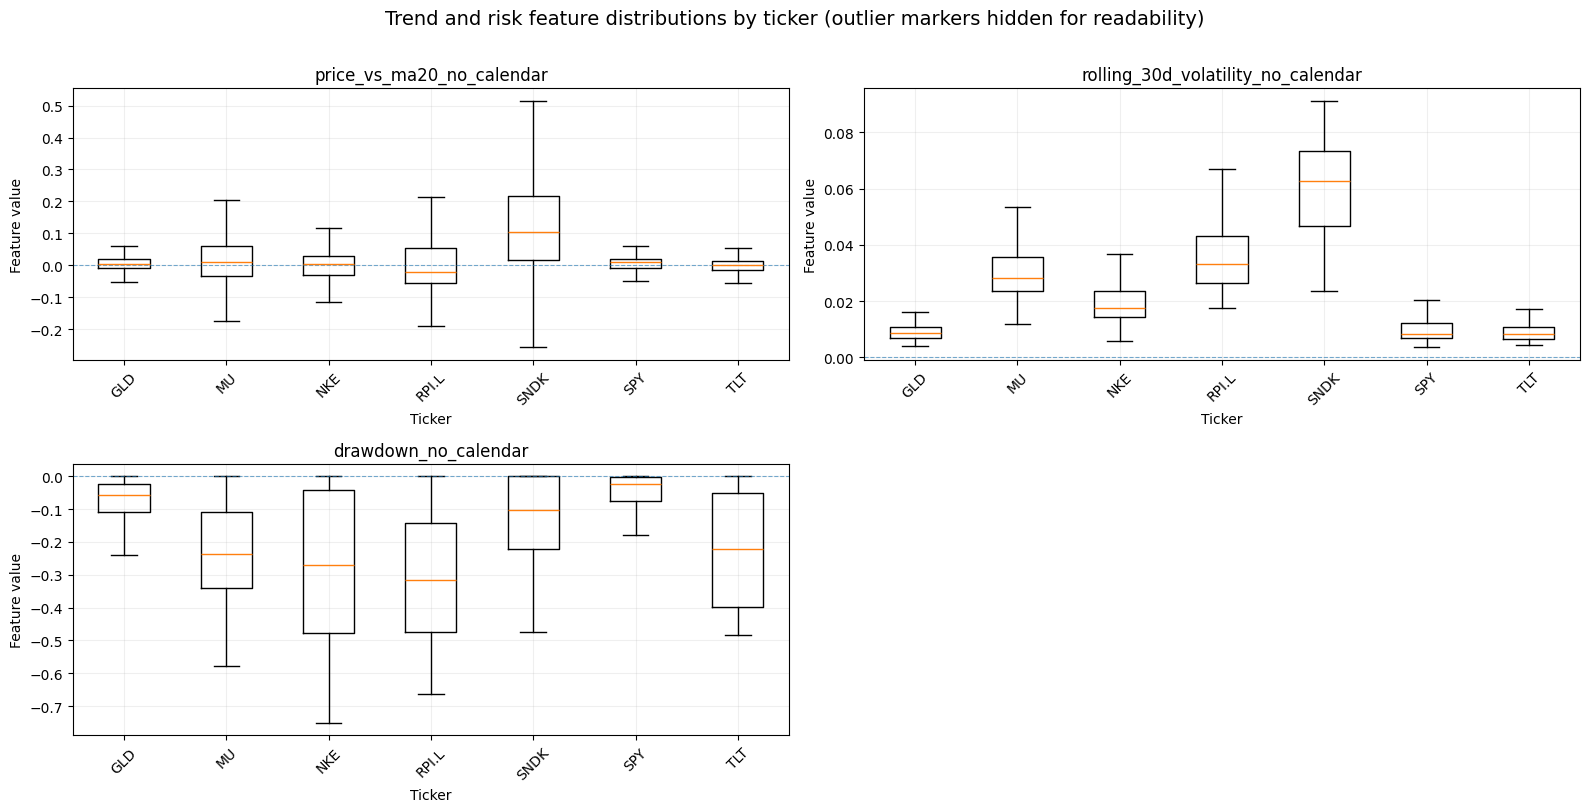

Graph 12:


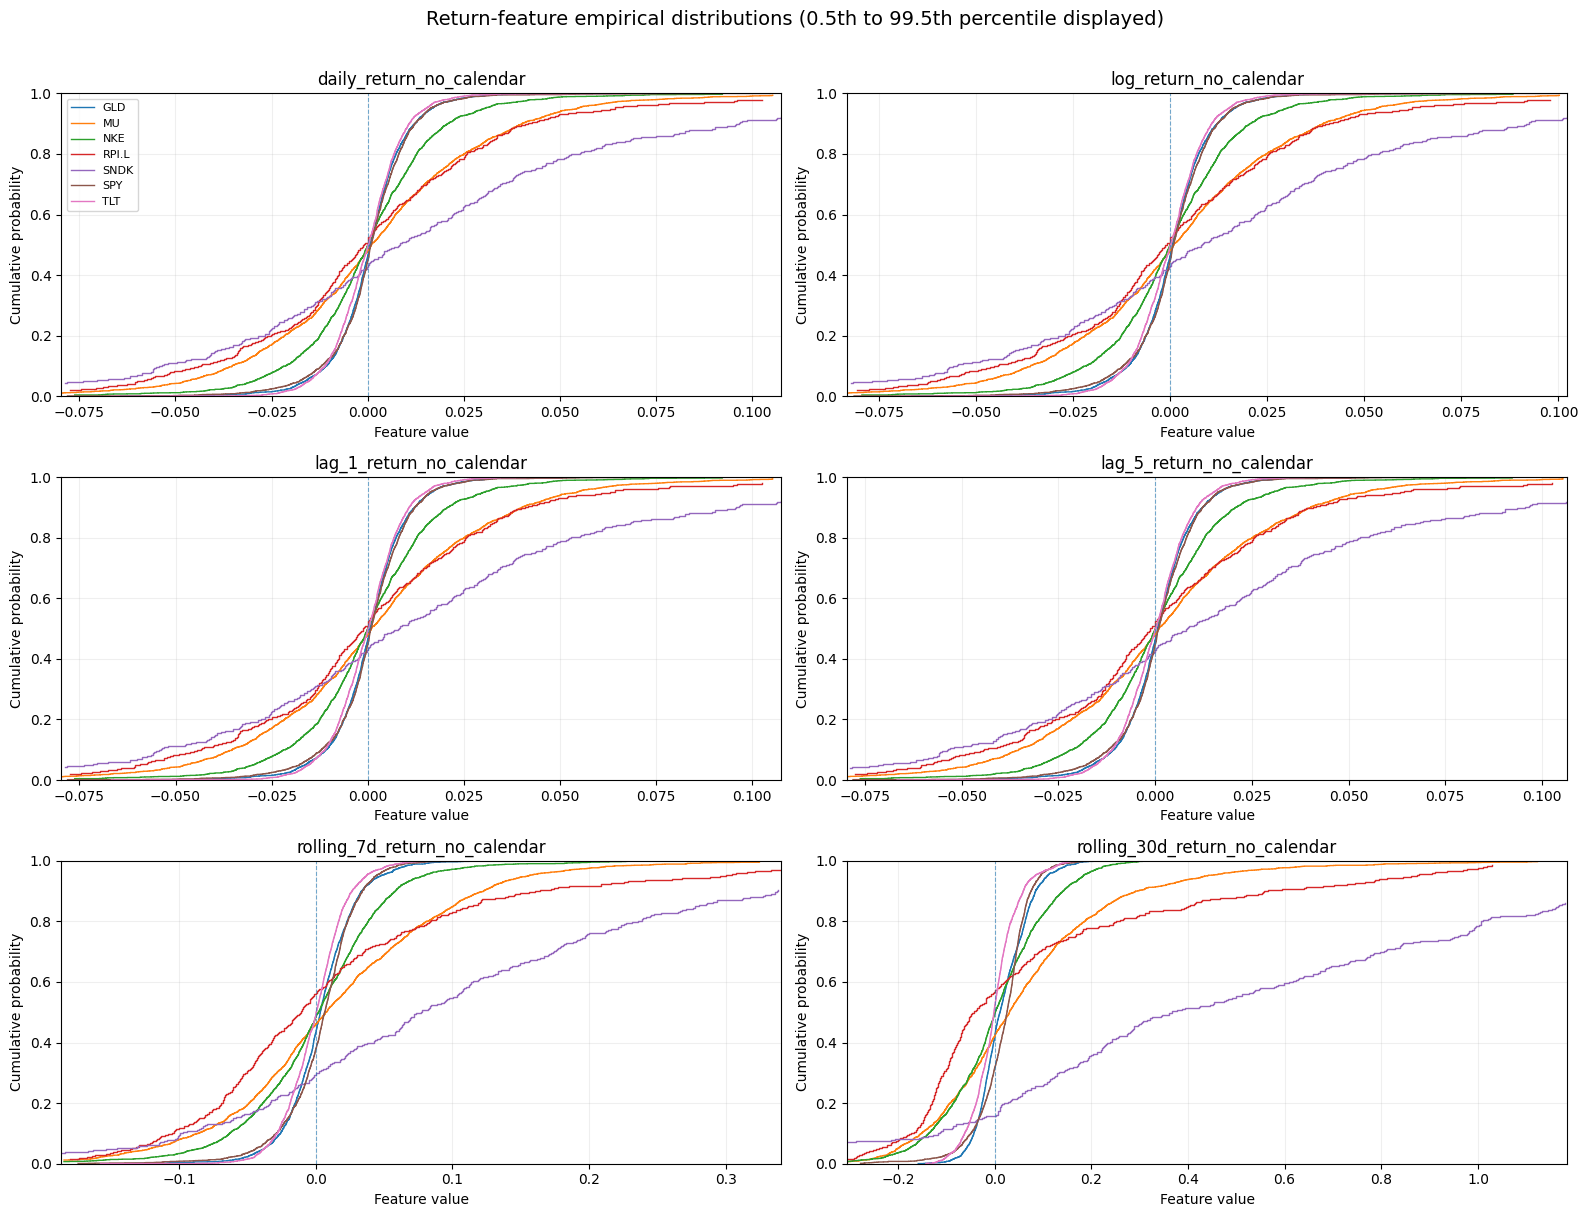

Graph 13:


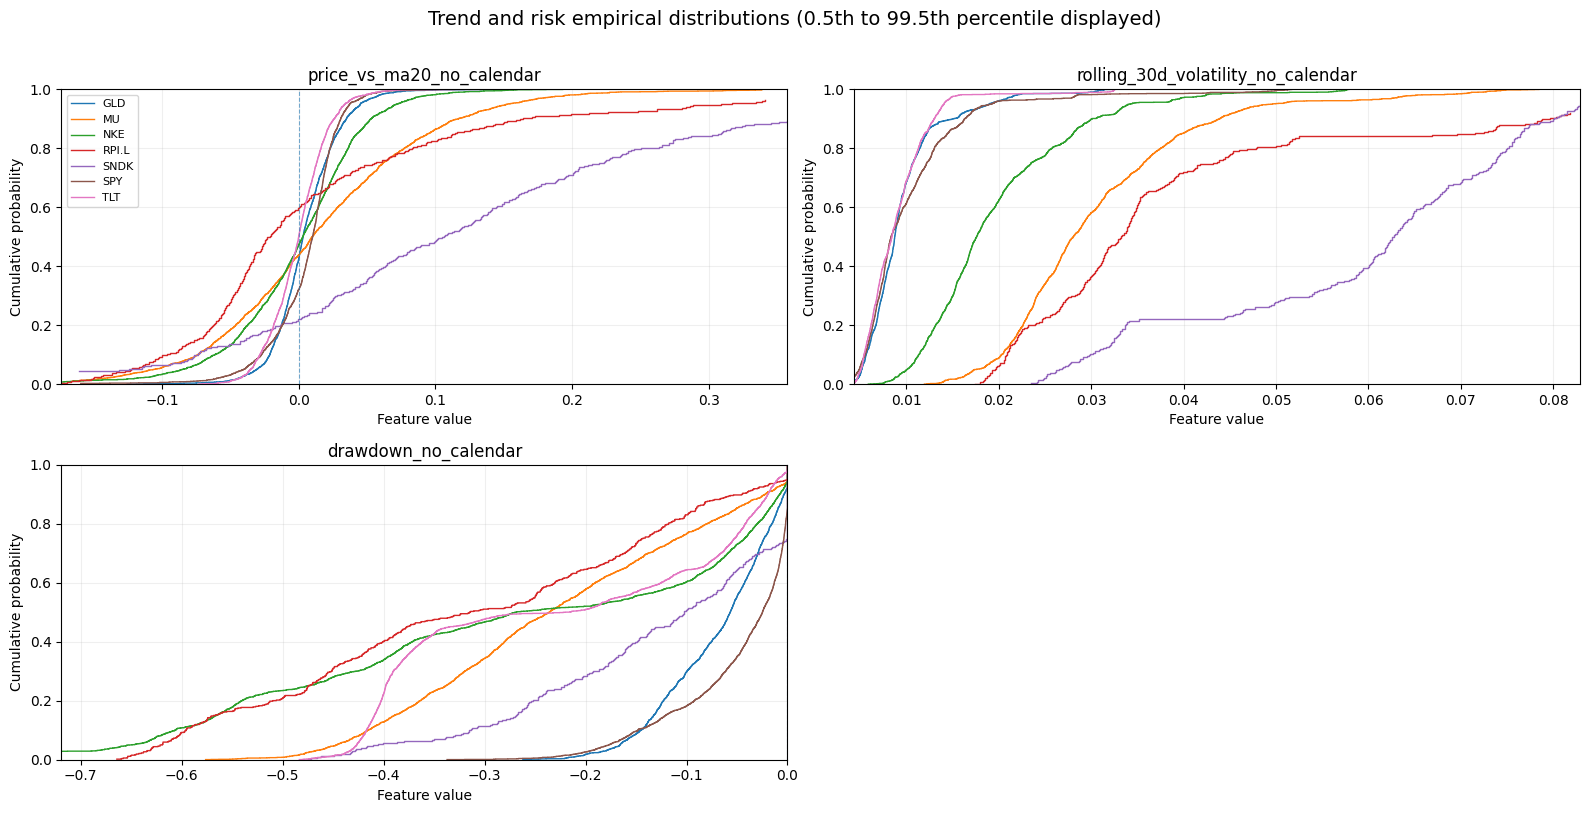

Table 24:
Median within-ticker Spearman correlation:


,daily_return_no_calendar,log_return_no_calendar,lag_1_return_no_calendar,lag_5_return_no_calendar,rolling_7d_return_no_calendar,rolling_30d_return_no_calendar,price_vs_ma20_no_calendar,relative_volume_no_calendar,rolling_30d_volatility_no_calendar,drawdown_no_calendar
daily_return_no_calendar,1.000000,1.000000,-0.027468,-0.002557,0.337666,0.164356,0.341641,-0.010507,0.021296,0.169204
log_return_no_calendar,1.000000,1.000000,-0.027468,-0.002557,0.337666,0.164356,0.341641,-0.010507,0.021296,0.169204
lag_1_return_no_calendar,-0.027468,-0.027468,1.000000,-0.019120,0.328003,0.157696,0.313129,0.004705,0.022233,0.140005
lag_5_return_no_calendar,-0.002557,-0.002557,-0.019120,1.000000,0.327592,0.158543,0.238099,0.031573,0.014520,0.119064
rolling_7d_return_no_calendar,0.337666,0.337666,0.328003,0.327592,1.000000,0.453172,0.821175,-0.015692,0.025750,0.329901
rolling_30d_return_no_calendar,0.164356,0.164356,0.157696,0.158543,0.453172,1.000000,0.667204,-0.025538,0.056143,0.528521
price_vs_ma20_no_calendar,0.341641,0.341641,0.313129,0.238099,0.821175,0.667204,1.000000,-0.075682,0.013435,0.452881
relative_volume_no_calendar,-0.010507,-0.010507,0.004705,0.031573,-0.015692,-0.025538,-0.075682,1.000000,-0.109938,-0.014920
rolling_30d_volatility_no_calendar,0.021296,0.021296,0.022233,0.014520,0.025750,0.056143,0.013435,-0.109938,1.000000,-0.038184
drawdown_no_calendar,0.169204,0.169204,0.140005,0.119064,0.329901,0.528521,0.452881,-0.014920,-0.038184,1.000000


Table 25:
Interquartile range of ticker-level correlations:


,daily_return_no_calendar,log_return_no_calendar,lag_1_return_no_calendar,lag_5_return_no_calendar,rolling_7d_return_no_calendar,rolling_30d_return_no_calendar,price_vs_ma20_no_calendar,relative_volume_no_calendar,rolling_30d_volatility_no_calendar,drawdown_no_calendar
daily_return_no_calendar,0.000000,0.000000,0.006381,0.013503,0.008718,0.009031,0.017233,0.068701,0.028066,0.060577
log_return_no_calendar,0.000000,0.000000,0.006381,0.013503,0.008718,0.009031,0.017233,0.068701,0.028066,0.060577
lag_1_return_no_calendar,0.006381,0.006381,0.000000,0.042722,0.012498,0.006210,0.005909,0.117890,0.023221,0.062833
lag_5_return_no_calendar,0.013503,0.013503,0.042722,0.000000,0.011886,0.012672,0.019597,0.084582,0.037583,0.057917
rolling_7d_return_no_calendar,0.008718,0.008718,0.012498,0.011886,0.000000,0.033931,0.023346,0.224279,0.094747,0.082977
rolling_30d_return_no_calendar,0.009031,0.009031,0.006210,0.012672,0.033931,0.000000,0.026833,0.130497,0.294703,0.101105
price_vs_ma20_no_calendar,0.017233,0.017233,0.005909,0.019597,0.023346,0.026833,0.000000,0.261479,0.128670,0.122412
relative_volume_no_calendar,0.068701,0.068701,0.117890,0.084582,0.224279,0.130497,0.261479,0.000000,0.088940,0.121080
rolling_30d_volatility_no_calendar,0.028066,0.028066,0.023221,0.037583,0.094747,0.294703,0.128670,0.088940,0.000000,0.377434
drawdown_no_calendar,0.060577,0.060577,0.062833,0.057917,0.082977,0.101105,0.122412,0.121080,0.377434,0.000000


Graph 14:


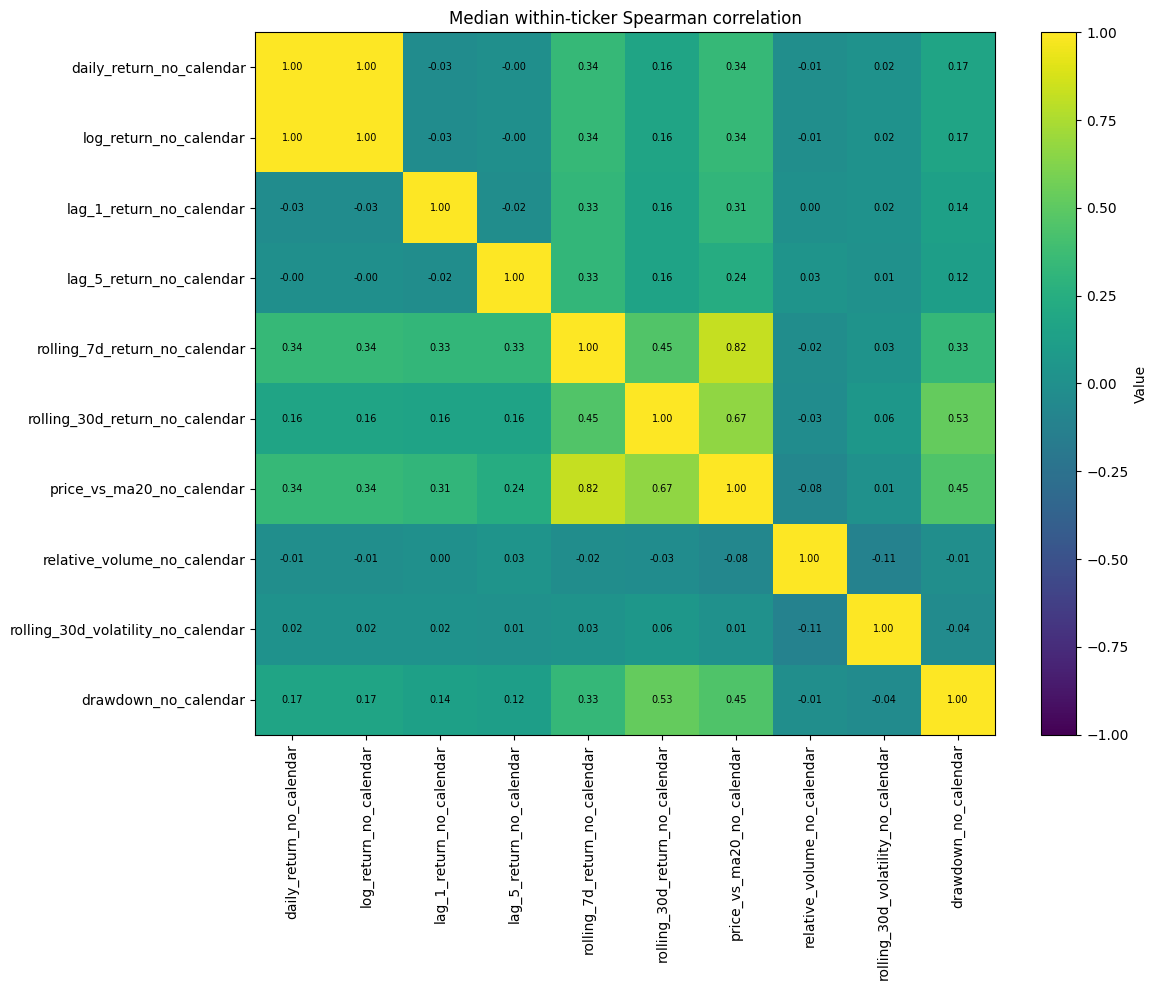

Graph 15:


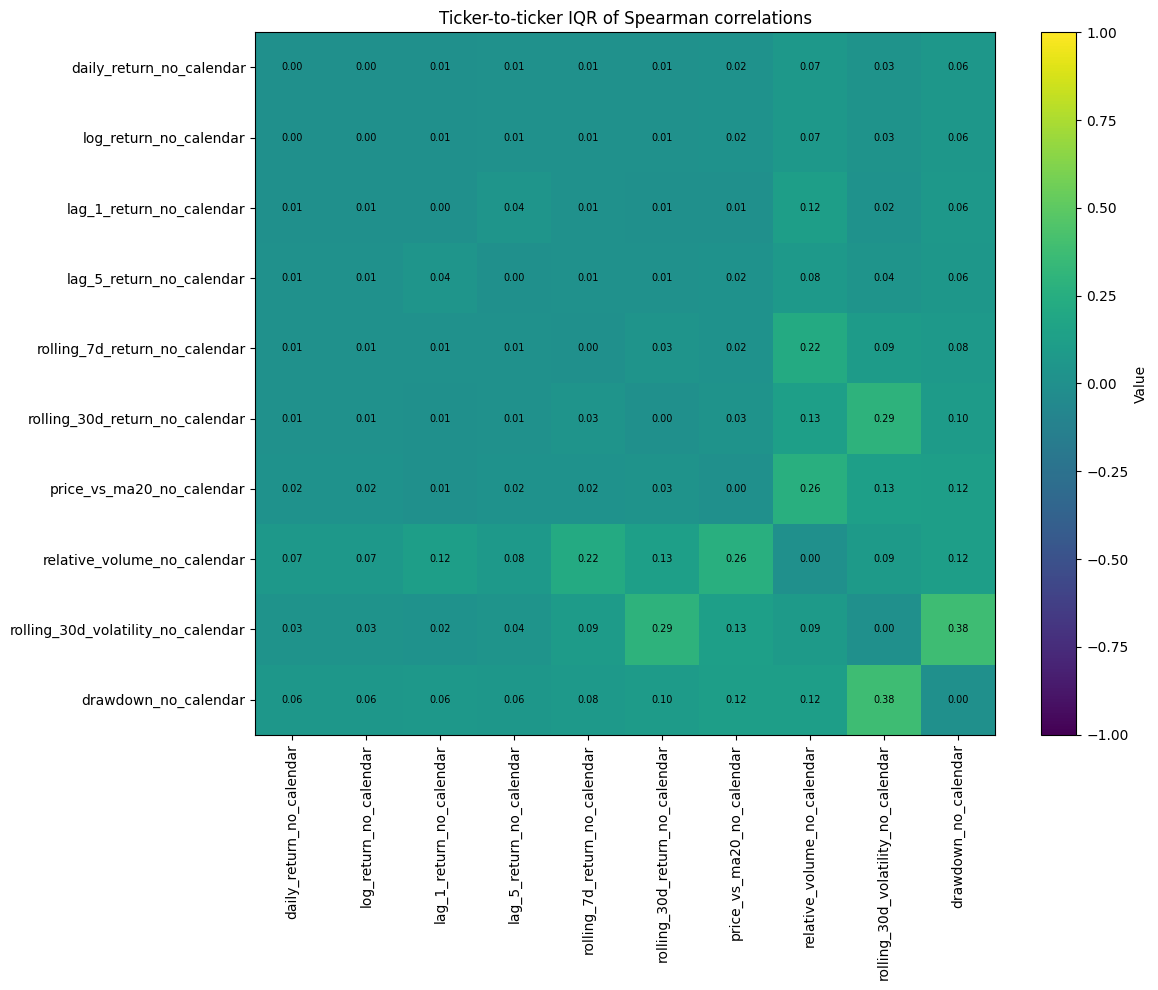

Table 26:
Next-day target-return summary:


,Count,Mean,Median,Std,Minimum,Maximum,Skewness
ticker,,,,,,,
GLD,2133,0.000564,0.000619,0.010588,-0.102742,0.063587,-0.636367
MU,2133,0.002091,0.001012,0.033101,-0.198186,0.192916,0.175578
NKE,2133,0.000087,0.000000,0.021387,-0.199809,0.155314,-0.268748
RPI.L,518,0.002499,-0.001033,0.047394,-0.139640,0.470910,3.267675
SNDK,344,0.014118,0.008176,0.064327,-0.213016,0.286494,0.345475
SPY,2133,0.000614,0.000900,0.012091,-0.109424,0.105019,-0.294439
TLT,2133,-0.000013,0.000123,0.009738,-0.066683,0.075196,0.161246


Table 27:
Target-direction balance:


,Valid_rows,Positive_rate,Positive rate %
ticker,,,
GLD,2133,0.538209,53.82091
MU,2133,0.521331,52.133146
NKE,2133,0.499297,49.929677
RPI.L,518,0.474903,47.490347
SNDK,344,0.569767,56.976744
SPY,2133,0.55368,55.368026
TLT,2133,0.503985,50.3985


In [52]:
# ============================================================
# SECTION: CHECKING FEATURE DISTRIBUTIONS
# ============================================================

DISTRIBUTION_FEATURES = [
    DAILY_RETURN_COL,
    LOG_RETURN_COL,
    LAG_1_RETURN_COL,
    LAG_5_RETURN_COL,
    ROLLING_7_RETURN_COL,
    ROLLING_30_RETURN_COL,
    PRICE_VS_MA20_COL,
    ROLLING_VOLATILITY_COL,
    DRAWDOWN_COL,
]

RETURN_DISTRIBUTION_FEATURES = [
    DAILY_RETURN_COL,
    LOG_RETURN_COL,
    LAG_1_RETURN_COL,
    LAG_5_RETURN_COL,
    ROLLING_7_RETURN_COL,
    ROLLING_30_RETURN_COL,
]

TREND_RISK_DISTRIBUTION_FEATURES = [
    PRICE_VS_MA20_COL,
    ROLLING_VOLATILITY_COL,
    DRAWDOWN_COL,
]


# ------------------------------------------------------------
# 1. Distribution summary matrix
# ------------------------------------------------------------

distribution_summary_records = []

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    for feature in DISTRIBUTION_FEATURES:
        values = finite_numeric(
            group[feature]
        )

        if len(values) == 0:
            distribution_summary_records.append(
                {
                    "Ticker": ticker,
                    "Feature": feature,
                    "Count": 0,
                    "Missing %": group[feature].isna().mean() * 100,
                    "Mean": np.nan,
                    "Median": np.nan,
                    "Std": np.nan,
                    "P1": np.nan,
                    "P5": np.nan,
                    "P25": np.nan,
                    "P75": np.nan,
                    "P95": np.nan,
                    "P99": np.nan,
                    "Minimum": np.nan,
                    "Maximum": np.nan,
                    "Skewness": np.nan,
                    "IQR": np.nan,
                    "IQR outlier %": np.nan,
                }
            )
            continue

        q1 = values.quantile(0.25)
        q3 = values.quantile(0.75)
        iqr = q3 - q1

        lower_bound = q1 - 1.5 * iqr
        upper_bound = q3 + 1.5 * iqr

        iqr_outlier_percentage = (
            (
                values.lt(lower_bound)
                | values.gt(upper_bound)
            ).mean()
            * 100
        )

        distribution_summary_records.append(
            {
                "Ticker": ticker,
                "Feature": feature,
                "Count": len(values),
                "Missing %": group[feature].isna().mean() * 100,
                "Mean": values.mean(),
                "Median": values.median(),
                "Std": values.std(),
                "P1": values.quantile(0.01),
                "P5": values.quantile(0.05),
                "P25": q1,
                "P75": q3,
                "P95": values.quantile(0.95),
                "P99": values.quantile(0.99),
                "Minimum": values.min(),
                "Maximum": values.max(),
                "Skewness": values.skew(),
                "IQR": iqr,
                "IQR outlier %": iqr_outlier_percentage,
            }
        )

distribution_summary_matrix = pd.DataFrame(
    distribution_summary_records
)

table_count += 1
print(f"Table {table_count}:")

display(distribution_summary_matrix)


# ------------------------------------------------------------
# 2. Compact cross-ticker scale and skewness matrices
# ------------------------------------------------------------

feature_skewness_matrix = (
    distribution_summary_matrix
    .pivot(
        index="Ticker",
        columns="Feature",
        values="Skewness"
    )
)

feature_standard_deviation_matrix = (
    distribution_summary_matrix
    .pivot(
        index="Ticker",
        columns="Feature",
        values="Std"
    )
)

feature_outlier_percentage_matrix = (
    distribution_summary_matrix
    .pivot(
        index="Ticker",
        columns="Feature",
        values="IQR outlier %"
    )
)

table_count += 1
print(f"Table {table_count}:")

print("Skewness matrix:")
display(feature_skewness_matrix)

table_count += 1
print(f"Table {table_count}:")

print("Standard-deviation matrix:")
display(feature_standard_deviation_matrix)

table_count += 1
print(f"Table {table_count}:")

print("IQR-outlier percentage matrix:")
display(feature_outlier_percentage_matrix)


# ------------------------------------------------------------
# 3. Boxplot helper
# ------------------------------------------------------------

def plot_feature_boxplot_grid(
    data: pd.DataFrame,
    features: list[str],
    title: str,
    ncols: int = 2
) -> None:

    nrows = math.ceil(len(features) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 4 * nrows),
        squeeze=False,
    )

    axes = axes.flatten()

    for axis, feature in zip(axes, features):
        boxplot_data = []

        for ticker in TICKERS_IN_DATA:
            ticker_values = finite_numeric(
                data.loc[
                    data[TICKER_COL].eq(ticker),
                    feature
                ]
            ).to_numpy()

            boxplot_data.append(ticker_values)

        # labels works across a wider range of matplotlib versions.
        axis.boxplot(
            boxplot_data,
            labels=[str(ticker) for ticker in TICKERS_IN_DATA],
            showfliers=False,
        )

        axis.axhline(
            0,
            linestyle="--",
            linewidth=0.8,
            alpha=0.6,
        )

        axis.set_title(feature)
        axis.set_xlabel("Ticker")
        axis.set_ylabel("Feature value")
        axis.tick_params(
            axis="x",
            rotation=45
        )
        axis.grid(alpha=0.2)

    for axis in axes[len(features):]:
        axis.set_visible(False)

    fig.suptitle(
        title,
        fontsize=14,
        y=1.01,
    )

    plt.tight_layout()
    
    plt.show()

graph_count += 1
print(f"Graph {graph_count}:")

plot_feature_boxplot_grid(
    data=feature_df,
    features=RETURN_DISTRIBUTION_FEATURES,
    title=(
        "Return-feature distributions by ticker "
        "(outlier markers hidden for readability)"
    ),
    ncols=2,
)

graph_count += 1
print(f"Graph {graph_count}:")

plot_feature_boxplot_grid(
    data=feature_df,
    features=TREND_RISK_DISTRIBUTION_FEATURES,
    title=(
        "Trend and risk feature distributions by ticker "
        "(outlier markers hidden for readability)"
    ),
    ncols=2,
)


# ------------------------------------------------------------
# 4. ECDF helper
# ------------------------------------------------------------

def plot_feature_ecdf_grid(
    data: pd.DataFrame,
    features: list[str],
    title: str,
    ncols: int = 2,
    truncate_to_percentiles: tuple[float, float] = (0.005, 0.995)
) -> None:

    nrows = math.ceil(len(features) / ncols)

    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(16, 4 * nrows),
        squeeze=False,
    )

    axes = axes.flatten()

    lower_quantile, upper_quantile = truncate_to_percentiles

    for axis, feature in zip(axes, features):
        all_values = finite_numeric(
            data[feature]
        )

        if len(all_values) == 0:
            axis.set_visible(False)
            continue

        lower_limit = all_values.quantile(
            lower_quantile
        )

        upper_limit = all_values.quantile(
            upper_quantile
        )

        for ticker, group in data.groupby(
            TICKER_COL,
            sort=False
        ):
            x_values, y_values = ecdf_values(
                group[feature]
            )

            display_mask = (
                (x_values >= lower_limit)
                & (x_values <= upper_limit)
            )

            axis.step(
                x_values[display_mask],
                y_values[display_mask],
                where="post",
                label=str(ticker),
                linewidth=1.0,
            )

        axis.axvline(
            0,
            linestyle="--",
            linewidth=0.8,
            alpha=0.6,
        )

        axis.set_xlim(
            lower_limit,
            upper_limit
        )

        axis.set_ylim(0, 1)
        axis.set_title(feature)
        axis.set_xlabel("Feature value")
        axis.set_ylabel("Cumulative probability")
        axis.grid(alpha=0.2)

    for axis in axes[len(features):]:
        axis.set_visible(False)

    visible_axes = [
        axis for axis in axes
        if axis.get_visible()
    ]

    if visible_axes:
        visible_axes[0].legend(
            loc="best",
            fontsize=8
        )

    fig.suptitle(
        title,
        fontsize=14,
        y=1.01,
    )

    plt.tight_layout()

    plt.show()


graph_count += 1
print(f"Graph {graph_count}:")

plot_feature_ecdf_grid(
    data=feature_df,
    features=RETURN_DISTRIBUTION_FEATURES,
    title=(
        "Return-feature empirical distributions "
        "(0.5th to 99.5th percentile displayed)"
    ),
    ncols=2,
)

graph_count += 1
print(f"Graph {graph_count}:")

plot_feature_ecdf_grid(
    data=feature_df,
    features=TREND_RISK_DISTRIBUTION_FEATURES,
    title=(
        "Trend and risk empirical distributions "
        "(0.5th to 99.5th percentile displayed)"
    ),
    ncols=2,
)


# ------------------------------------------------------------
# 5. Spearman predictor-correlation matrices
# ------------------------------------------------------------

CORRELATION_FEATURES = [
    DAILY_RETURN_COL,
    LOG_RETURN_COL,
    LAG_1_RETURN_COL,
    LAG_5_RETURN_COL,
    ROLLING_7_RETURN_COL,
    ROLLING_30_RETURN_COL,
    PRICE_VS_MA20_COL,
    RELATIVE_VOLUME_COL,
    ROLLING_VOLATILITY_COL,
    DRAWDOWN_COL,
]

ticker_correlation_matrices = {}

for ticker, group in feature_df.groupby(TICKER_COL, sort=False):
    ticker_matrix = (
        group[CORRELATION_FEATURES]
        .replace([np.inf, -np.inf], np.nan)
        .corr(
            method="spearman",
            min_periods=30
        )
    )

    ticker_correlation_matrices[ticker] = (
        ticker_matrix
    )

correlation_stack = np.stack(
    [
        matrix.to_numpy()
        for matrix in ticker_correlation_matrices.values()
    ],
    axis=0,
)

median_correlation_matrix = pd.DataFrame(
    np.nanmedian(
        correlation_stack,
        axis=0
    ),
    index=CORRELATION_FEATURES,
    columns=CORRELATION_FEATURES,
)

correlation_iqr_matrix = pd.DataFrame(
    (
        np.nanpercentile(
            correlation_stack,
            75,
            axis=0
        )
        -
        np.nanpercentile(
            correlation_stack,
            25,
            axis=0
        )
    ),
    index=CORRELATION_FEATURES,
    columns=CORRELATION_FEATURES,
)

table_count += 1
print(f"Table {table_count}:")

print("Median within-ticker Spearman correlation:")
display(median_correlation_matrix)

table_count += 1
print(f"Table {table_count}:")

print("Interquartile range of ticker-level correlations:")
display(correlation_iqr_matrix)


# ------------------------------------------------------------
# 6. Correlation heatmap helper
# ------------------------------------------------------------

def plot_matrix_heatmap(
    matrix: pd.DataFrame,
    title: str,
    value_format: str = ".2f",
    annotate: bool = True
) -> None:

    fig, ax = plt.subplots(
        figsize=(12, 10)
    )

    image = ax.imshow(
        matrix.to_numpy(dtype=float),
        aspect="auto",
        vmin=-1 if "correlation" in title.lower() else None,
        vmax=1 if "correlation" in title.lower() else None,
    )

    ax.set_xticks(
        np.arange(len(matrix.columns))
    )

    ax.set_xticklabels(
        matrix.columns,
        rotation=90
    )

    ax.set_yticks(
        np.arange(len(matrix.index))
    )

    ax.set_yticklabels(
        matrix.index
    )

    if annotate:
        for row_position in range(
            len(matrix.index)
        ):
            for column_position in range(
                len(matrix.columns)
            ):
                value = matrix.iloc[
                    row_position,
                    column_position
                ]

                if pd.notna(value):
                    ax.text(
                        column_position,
                        row_position,
                        format(value, value_format),
                        ha="center",
                        va="center",
                        fontsize=7,
                    )

    ax.set_title(title)

    colorbar = fig.colorbar(
        image,
        ax=ax
    )

    colorbar.set_label("Value")

    plt.tight_layout()

    plt.show()


graph_count += 1
print(f"Graph {graph_count}:")

plot_matrix_heatmap(
    median_correlation_matrix,
    title="Median within-ticker Spearman correlation",
)

graph_count += 1
print(f"Graph {graph_count}:")

plot_matrix_heatmap(
    correlation_iqr_matrix,
    title="Ticker-to-ticker IQR of Spearman correlations",
)


# ------------------------------------------------------------
# 7. Separate target-distribution summaries
# ------------------------------------------------------------

target_return_summary = (
    feature_df
    .replace([np.inf, -np.inf], np.nan)
    .groupby(TICKER_COL)[TARGET_RETURN_COL]
    .agg(
        Count="count",
        Mean="mean",
        Median="median",
        Std="std",
        Minimum="min",
        Maximum="max",
        Skewness="skew",
    )
)

target_direction_balance = (
    feature_df
    .groupby(TICKER_COL)[TARGET_DIRECTION_COL]
    .agg(
        Valid_rows="count",
        Positive_rate="mean",
    )
)

target_direction_balance["Positive rate %"] = (
    target_direction_balance[
        "Positive_rate"
    ]
    * 100
)

table_count += 1
print(f"Table {table_count}:")

print("Next-day target-return summary:")
display(target_return_summary)

table_count += 1
print(f"Table {table_count}:")

print("Target-direction balance:")
display(target_direction_balance)